# Healthcare and Census Data Massachusetts 2011-2025

**Next steps**
*   Extract some features and include in pipeline:


1.   Population Density
2.   Healthcare Coverage
3.   Provider Density --> tbd whether to tweak




## 0 Setup

In [20]:
overall_setup = """
Overall setup for the Massachusetts Census and Healthcare Access pipeline.

This block:
1. Mounts Google Drive.
2. Defines the shared project folder.
3. Creates and uses the Census_Healthcare_Data folder shown in Google Drive.
4. Installs required Python packages.
5. Defines shared constants used by later blocks.

Run this block first.
"""

from google.colab import drive, userdata
drive.mount("/content/drive", force_remount=True)

!pip install -q pandas requests beautifulsoup4 tqdm

import os
import re
import time
import zipfile
import requests
import pandas as pd

from bs4 import BeautifulSoup
from tqdm import tqdm

PROJECT_PATH = "/content/drive/MyDrive/MASAID/EHR_TechnicalDifficulties_Share"
DATA_FOLDER = "Census_Healthcare_Data"
BASE_PATH = os.path.join(PROJECT_PATH, DATA_FOLDER)

os.makedirs(BASE_PATH, exist_ok=True)

START_YEAR = 2011
END_YEAR = 2025

MA_ZCTA_PREFIXES = ("01", "02")

CENSUS_API_KEY = userdata.get("CENSUS_API_KEY")

print(f"All files will be saved here:\n{BASE_PATH}")

Mounted at /content/drive
All files will be saved here:
/content/drive/MyDrive/MASAID/EHR_TechnicalDifficulties_Share/Census_Healthcare_Data


## 1 Census Data

### 1.1 Census Data

In [21]:
# Overall Setup

"""
Population Density Pipeline — Setup

Purpose
-------
Initializes the environment, dependencies, constants, and file paths
required for building a Massachusetts population density dataset.

Scope
-----
- Installs required geospatial and plotting libraries
- Imports core dependencies (data handling, HTTP, geospatial, plotting)
- Defines project directory structure
- Sets analysis parameters (year range, geographic filters)
- Configures output file locations

Key Assumptions
---------------
- Data is sourced from the U.S. Census Bureau (ACS + Gazetteer + TIGER)
- Massachusetts ZCTAs are approximated using ZIP prefixes ('01', '02')
- Output directory is writable

Outputs
-------
Defines file paths for:
- ZCTA-level population density dataset
- County-level aggregated density dataset
- County-level density choropleth map

Notes
-----
- Designed for reproducibility in notebook or pipeline execution
- All downstream functions depend on these constants
"""

!pip install -q geopandas matplotlib pyogrio

import os
import time
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Base output directory
BASE_PATH = "Census_Healthcare_Data"
os.makedirs(BASE_PATH, exist_ok=True)

# Analysis parameters
START_YEAR = 2011
END_YEAR = 2025

# Massachusetts ZCTA approximation (ZIP prefixes)
MA_ZCTA_PREFIXES = ("01", "02")

# Output file paths
POPULATION_OUTPUT_FILE = os.path.join(
    BASE_PATH,
    "massachusetts_zcta_density_2011_2025.csv"
)

COUNTY_DENSITY_OUTPUT_FILE = os.path.join(
    BASE_PATH,
    "massachusetts_county_density_2011_2025.csv"
)

COUNTY_DENSITY_MAP_OUTPUT_FILE = os.path.join(
    BASE_PATH,
    "massachusetts_county_population_density_map_latest_year.png"
)

In [22]:
def fetch_acs_population_data(year, api_key=None):
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": "NAME,B01003_001E",
        "for": "zip code tabulation area:*"
    }
    if api_key:
        params["key"] = api_key

    try:
        response = requests.get(url, params=params, timeout=90)
    except requests.exceptions.RequestException as exc:
        print(f"Skipping {year}: request failed: {exc}")
        return None

    if response.status_code != 200:
        print(f"Skipping {year}: ACS endpoint unavailable. Status code: {response.status_code}. Response text: {response.text[:200]}...")
        return None

    try:
        data = response.json()
    except ValueError:
        print(f"Skipping {year}: non-JSON response. Response text: {response.text[:200]}...")
        return None

    if len(data) < 2:
        print(f"Skipping {year}: no data returned.")
        return None

    df = pd.DataFrame(data[1:], columns=data[0])

    df = df.rename(columns={
        "B01003_001E": "population",
        "zip code tabulation area": "zcta"
    })

    df["year"] = year
    df["zcta"] = df["zcta"].astype(str).str.zfill(5)
    df["population"] = pd.to_numeric(df["population"], errors="coerce")

    return df[["year", "zcta", "population"]]

In [23]:
# Land area

def load_zcta_land_area():
    url = (
        "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/"
        "2020_Gazetteer/2020_Gaz_zcta_national.zip"
    )

    df = pd.read_csv(url, compression="zip", sep="\t")
    df.columns = df.columns.str.strip()

    df = df.rename(columns={
        "GEOID": "zcta",
        "ALAND_SQMI": "area_sq_miles"
    })

    df["zcta"] = df["zcta"].astype(str).str.zfill(5)
    df["area_sq_miles"] = pd.to_numeric(df["area_sq_miles"], errors="coerce")

    return df[["zcta", "area_sq_miles"]]

In [24]:
# ZCTA-to-county crosswalk

def load_zcta_county_crosswalk():
    """
    Load Census 2020 ZCTA-to-county relationship data.

    Uses explicit Census relationship columns:
    - geoid_zcta5_20
    - geoid_county_20

    Keeps only Massachusetts counties.
    """
    url = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/zcta520/tab20_zcta520_county20_natl.txt"

    df = pd.read_csv(url, sep="|", dtype=str)
    df.columns = df.columns.str.lower().str.strip()

    print("Crosswalk columns:")
    print(df.columns.tolist())

    zcta_col = "geoid_zcta5_20"
    county_col = "geoid_county_20"

    if zcta_col not in df.columns:
        raise RuntimeError(f"Missing expected column: {zcta_col}")

    if county_col not in df.columns:
        raise RuntimeError(f"Missing expected column: {county_col}")

    df["zcta"] = (
        df[zcta_col]
        .astype(str)
        .str.extract(r"(\d{5})$")[0]
        .str.zfill(5)
    )

    df["county_fips"] = (
        df[county_col]
        .astype(str)
        .str.extract(r"(\d{5})$")[0]
    )

    df = df[df["county_fips"].str.startswith("25", na=False)].copy()

    county_names = {
        "25001": "Barnstable County",
        "25003": "Berkshire County",
        "25005": "Bristol County",
        "25007": "Dukes County",
        "25009": "Essex County",
        "25011": "Franklin County",
        "25013": "Hampden County",
        "25015": "Hampshire County",
        "25017": "Middlesex County",
        "25019": "Nantucket County",
        "25021": "Norfolk County",
        "25023": "Plymouth County",
        "25025": "Suffolk County",
        "25027": "Worcester County",
    }

    df["county_name"] = df["county_fips"].map(county_names)

    crosswalk = (
        df[["zcta", "county_fips", "county_name"]]
        .dropna()
        .drop_duplicates(subset=["zcta"])
        .reset_index(drop=True)
    )

    print(f"Crosswalk mapping rows: {len(crosswalk):,}")
    print(crosswalk.head())

    return crosswalk

In [25]:
# Build ZCTA density dataset

def build_population_density_dataset():
    all_data = []

    for year in range(START_YEAR, END_YEAR + 1):
        print(f"Processing population year {year}...")
        df = fetch_acs_population_data(year, api_key=CENSUS_API_KEY)

        if df is not None and not df.empty:
            all_data.append(df)

        time.sleep(0.5)

    if not all_data:
        raise RuntimeError("No ACS population data downloaded.")

    population = pd.concat(all_data, ignore_index=True)

    population = population[
        population["zcta"].str.startswith(MA_ZCTA_PREFIXES)
    ].copy()

    land = load_zcta_land_area()
    county_crosswalk = load_zcta_county_crosswalk()

    df = population.merge(land, on="zcta", how="left")
    df = df.merge(county_crosswalk, on="zcta", how="left")

    df["density_per_sq_mile"] = df["population"] / df["area_sq_miles"]

    df["zip_code"] = df["zcta"]
    df["zip_mapping_method"] = "ZCTA equals ZIP approximation"

    df = df[[
        "year",
        "zip_code",
        "zcta",
        "county_fips",
        "county_name",
        "population",
        "area_sq_miles",
        "density_per_sq_mile",
        "zip_mapping_method"
    ]]

    return df.sort_values(["zip_code", "year"]).reset_index(drop=True)

In [26]:
# County aggregation

def build_county_density_dataset(zcta_density):
    """
    Aggregate ZCTA-level population density to county-level population density.
    Automatically adds county mapping if missing.
    """
    df = zcta_density.copy()

    if "zcta" not in df.columns:
        if "zip_code" in df.columns:
            df["zcta"] = df["zip_code"]
        elif "zip" in df.columns:
            df["zcta"] = df["zip"]
        else:
            raise RuntimeError("zcta_density needs a zcta, zip_code, or zip column.")

    df["zcta"] = (
        df["zcta"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .str.zfill(5)
    )

    if "county_fips" not in df.columns or "county_name" not in df.columns:
        print("Adding county mapping to population_density...")
        crosswalk = load_zcta_county_crosswalk()

        df = df.drop(columns=["county_fips", "county_name"], errors="ignore")

        df = df.merge(
            crosswalk,
            on="zcta",
            how="left"
        )

    matched = df["county_fips"].notna().sum()
    total = len(df)
    print(f"County mapping matched rows: {matched:,} / {total:,}")

    if matched == 0:
        raise RuntimeError(
            "No rows matched the ZCTA-to-county crosswalk. "
            "Check your ZCTA/ZIP values."
        )

    df = df.dropna(subset=["county_fips", "county_name"]).copy()

    for col in ["population", "area_sq_miles"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    county_density = (
        df.groupby(["year", "county_fips", "county_name"], as_index=False)
        .agg(
            population=("population", "sum"),
            area_sq_miles=("area_sq_miles", "sum"),
            zcta_count=("zcta", "nunique")
        )
    )

    county_density["density_per_sq_mile"] = (
        county_density["population"]
        / county_density["area_sq_miles"].replace({0: pd.NA})
    )

    return county_density.sort_values(
        ["year", "county_name"]
    ).reset_index(drop=True)

In [27]:
# Build population dataset
population_density = build_population_density_dataset()

# Save for reuse
population_density.to_csv(POPULATION_OUTPUT_FILE, index=False)

# Sanity check
print("Population dataset shape:", population_density.shape)
display(population_density.head())

Processing population year 2011...
Processing population year 2012...
Processing population year 2013...
Processing population year 2014...
Processing population year 2015...
Processing population year 2016...
Processing population year 2017...
Processing population year 2018...
Processing population year 2019...
Processing population year 2020...
Processing population year 2021...
Processing population year 2022...
Processing population year 2023...
Processing population year 2024...
Processing population year 2025...
Skipping 2025: ACS endpoint unavailable. Status code: 404. Response text: <!doctype html><html lang="en"><head><title>HTTP Status 404 ? Not Found</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} ...
Crosswalk columns:
['oid_zcta5_20', 'geoid_zcta5_20', 'namelsad_zcta5_20', 'arealand_zcta5_20', 'areawater_zcta5_20', 'mtfcc_zcta5_20', 'classfp_zcta5_20', 'funcstat_zcta5_20', 'oid_county_20', 'ge

,year,zip_code,zcta,county_fips,county_name,population,area_sq_miles,density_per_sq_mile,zip_mapping_method
0,2011,01001,01001,25013,Hampden County,16775,11.505,1458.061712,ZCTA equals ZIP approximation
1,2012,01001,01001,25013,Hampden County,17380,11.505,1510.647545,ZCTA equals ZIP approximation
2,2013,01001,01001,25013,Hampden County,17245,11.505,1498.913516,ZCTA equals ZIP approximation
3,2014,01001,01001,25013,Hampden County,17141,11.505,1489.873968,ZCTA equals ZIP approximation
4,2015,01001,01001,25013,Hampden County,17438,11.505,1515.688831,ZCTA equals ZIP approximation


In [28]:
# Build county dataset
county_density = build_county_density_dataset(population_density)

# Quick sanity check (before plotting)
print("Shape:", county_density.shape)
print(county_density["density_per_sq_mile"].describe())

County mapping matched rows: 7,490 / 8,620
Shape: (196, 7)
count      196.000000
mean      1676.061313
std       3300.439629
min        127.237995
25%        239.305276
50%        669.100829
75%       1578.222047
max      13895.411155
Name: density_per_sq_mile, dtype: float64


### 1.2 Census Data Map

In [29]:
# Map

def create_county_density_map(county_density):
    latest_year = int(county_density["year"].max())

    latest_density = county_density[
        county_density["year"] == latest_year
    ].copy()

    counties_url = (
        "https://www2.census.gov/geo/tiger/GENZ2020/shp/"
        "cb_2020_us_county_500k.zip"
    )

    counties = gpd.read_file(counties_url)
    counties = counties[counties["STATEFP"] == "25"].copy()
    counties["county_fips"] = counties["GEOID"].astype(str)

    map_df = counties.merge(latest_density, on="county_fips", how="left")

    fig, ax = plt.subplots(figsize=(10, 10))

    map_df.plot(
        column="density_per_sq_mile",
        legend=True,
        edgecolor="black",
        linewidth=0.6,
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    ax.set_title(
      f"Massachusetts Population Density by County, {latest_year}",
      fontsize=14
    )

    ax.axis("off")

    plt.tight_layout()

    # Save first
    plt.savefig(COUNTY_DENSITY_MAP_OUTPUT_FILE, dpi=300, bbox_inches="tight")

    # --- FORCE DISPLAY IN COLAB ---
    from IPython.display import display
    display(fig)

    plt.close(fig)  # prevents duplicate/ghost renders

    return map_df

Missing ZCTAs: 11


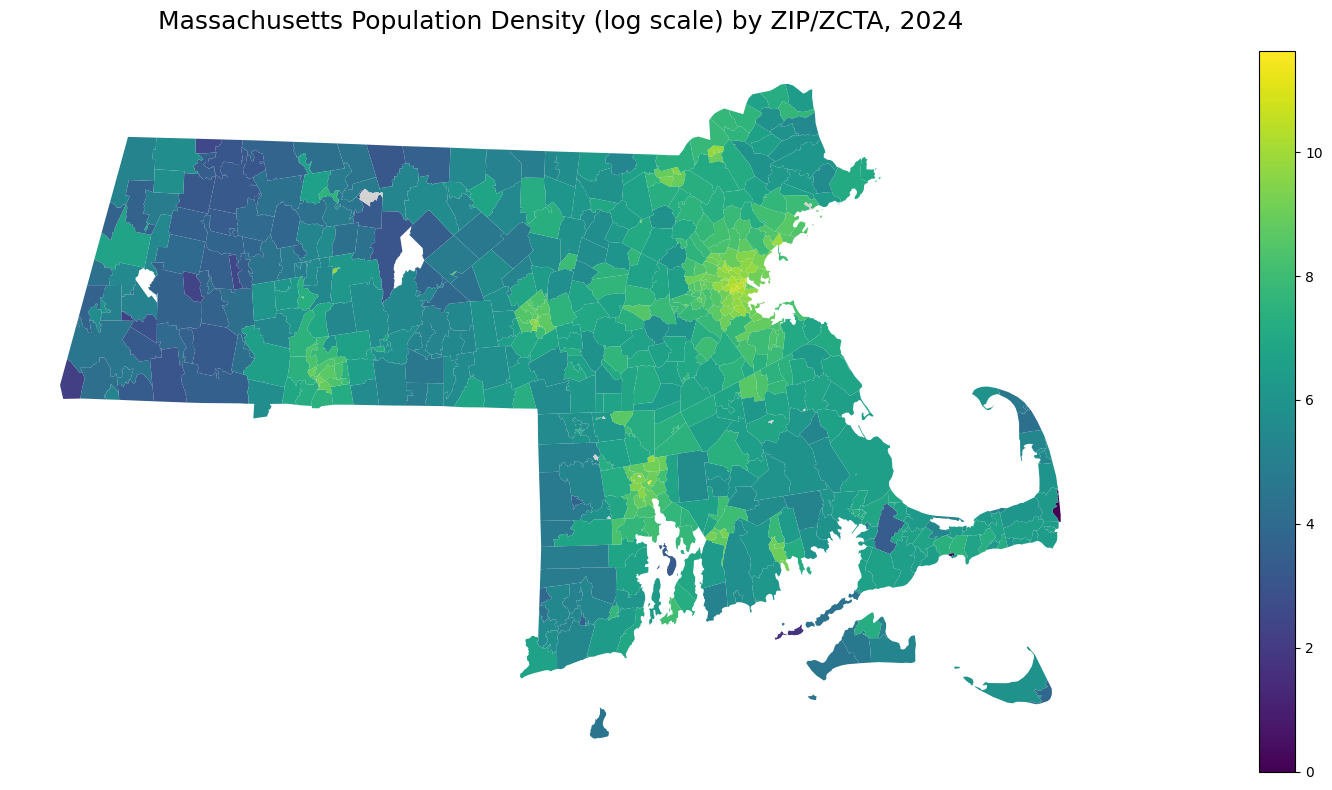

In [30]:
# Create + display map

import numpy as np
from IPython.display import display

latest_year = int(population_density["year"].max())

latest_population = population_density[
    population_density["year"] == latest_year
].copy()

latest_population["zcta"] = latest_population["zcta"].astype(str).str.zfill(5)

zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zcta"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

ma_zctas = zctas[
    zctas["zcta"].str.startswith(MA_ZCTA_PREFIXES, na=False)
].copy()

zcta_map_df = ma_zctas.merge(
    latest_population,
    on="zcta",
    how="left"
)

zcta_map_df["density_log"] = np.log1p(
    pd.to_numeric(zcta_map_df["density_per_sq_mile"], errors="coerce")
)

print("Missing ZCTAs:", zcta_map_df["density_per_sq_mile"].isna().sum())

fig, ax = plt.subplots(figsize=(30, 8))

zcta_map_df.plot(
    column="density_log",
    cmap="viridis",
    legend=True,
    edgecolor="none",
    linewidth=0,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    f"Massachusetts Population Density (log scale) by ZIP/ZCTA, {latest_year}",
    fontsize=18,
    pad=16
)

ax.axis("off")

plt.tight_layout()
display(fig)
plt.close(fig)

## 2 Healthcare Provider Density

### 2.1 Healthcare Provider Data

In [31]:
# Setup
"""
Diabetes-relevant healthcare-provider density pipeline.

This pipeline:
1. Downloads or reuses the latest CMS NPPES provider file.
2. Extracts Massachusetts diabetes-relevant providers.
3. Applies relevance weights by taxonomy.
4. Aggregates provider counts by ZIP/ZCTA.
5. Merges provider coverage with population-density data.
6. Saves provider detail, ZIP counts, and provider-density outputs.

Required before running:
- BASE_PATH must be defined.
- MA_ZCTA_PREFIXES should be defined.
- population_density should exist in memory OR a population-density CSV should exist in BASE_PATH.
"""

!pip install -q beautifulsoup4 tqdm

import os
import zipfile
import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

NPPES_PAGE = "https://download.cms.gov/nppes/NPI_Files.html"
NPPES_ZIP_PATH = os.path.join(BASE_PATH, "nppes_latest.zip")

PROVIDER_DETAIL_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_diabetes_relevant_provider_detail.csv"
)

PROVIDER_COUNTS_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_diabetes_relevant_provider_counts_by_zip.csv"
)

PROVIDER_DENSITY_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_diabetes_relevant_provider_density_by_zip_year.csv"
)

POPULATION_INPUT_FILE = os.path.join(
    BASE_PATH,
    "massachusetts_zcta_density_2011_2025.csv"
)

In [32]:
# Fix / locate population input file

def resolve_population_input_file():
    """
    Resolve the population-density input file.

    Priority:
    1. Existing POPULATION_INPUT_FILE.
    2. Existing population_density DataFrame in memory.
    3. Any likely population-density CSV in BASE_PATH.

    Returns
    -------
    str
        Valid CSV path.
    """
    if os.path.exists(POPULATION_INPUT_FILE):
        print(f"Using population file: {POPULATION_INPUT_FILE}")
        return POPULATION_INPUT_FILE

    if "population_density" in globals():
        print("POPULATION_INPUT_FILE not found. Saving population_density from memory.")
        population_density.to_csv(POPULATION_INPUT_FILE, index=False)
        print(f"Saved: {POPULATION_INPUT_FILE}")
        return POPULATION_INPUT_FILE

    candidates = [
        os.path.join(BASE_PATH, file)
        for file in os.listdir(BASE_PATH)
        if file.endswith(".csv")
        and (
            "zcta_density" in file
            or "population_density" in file
            or "massachusetts_zcta" in file
        )
    ]

    if candidates:
        selected = candidates[0]
        print(f"Using detected population file: {selected}")
        return selected

    raise FileNotFoundError(
        "No population-density CSV found. Re-run the population density block first."
    )


POPULATION_INPUT_FILE = resolve_population_input_file()

Using population file: Census_Healthcare_Data/massachusetts_zcta_density_2011_2025.csv


In [33]:
# Taxnomoy definitions

DOCTOR_TAXONOMIES = {
    "207RE0101X": "Endocrinology, Diabetes & Metabolism",
    "207Q00000X": "Family Medicine",
    "207R00000X": "Internal Medicine",
    "208D00000X": "General Practice",
    "208000000X": "Pediatrics",
    "207V00000X": "Obstetrics & Gynecology",
    "207W00000X": "Ophthalmology",
    "213E00000X": "Podiatrist",
    "207RN0300X": "Nephrology",
    "207RC0000X": "Cardiovascular Disease",
}

ADVANCED_PRACTICE_TAXONOMIES = {
    "363L00000X": "Nurse Practitioner",
    "363A00000X": "Physician Assistant",
}

NUTRITION_EDUCATION_TAXONOMIES = {
    "133V00000X": "Dietitian, Registered",
    "133VN1004X": "Nutrition, Pediatric",
    "133VN1005X": "Nutrition, Renal",
    "163WD0400X": "Diabetes Educator",
}

HOSPITAL_TAXONOMIES = {
    "282N00000X": "General Acute Care Hospital",
    "282NC0060X": "Critical Access Hospital",
    "282NR1301X": "Rural General Acute Care Hospital",
    "282NW0100X": "Women General Acute Care Hospital",
    "283X00000X": "Rehabilitation Hospital",
    "284300000X": "Special Hospital",
}

TAXONOMY_NAMES = {
    **DOCTOR_TAXONOMIES,
    **ADVANCED_PRACTICE_TAXONOMIES,
    **NUTRITION_EDUCATION_TAXONOMIES,
    **HOSPITAL_TAXONOMIES,
}

DIABETES_RELEVANCE_WEIGHTS = {
    "207RE0101X": 5,
    "207Q00000X": 5,
    "207R00000X": 5,
    "208D00000X": 4,
    "208000000X": 4,
    "207V00000X": 3,
    "207W00000X": 4,
    "213E00000X": 4,
    "207RN0300X": 4,
    "207RC0000X": 3,
    "363L00000X": 4,
    "363A00000X": 4,
    "133V00000X": 5,
    "133VN1004X": 4,
    "133VN1005X": 4,
    "163WD0400X": 5,
    "282N00000X": 3,
    "282NC0060X": 3,
    "282NR1301X": 3,
    "282NW0100X": 2,
    "283X00000X": 2,
    "284300000X": 2,
}

In [34]:
# NPPES download helpers

def get_latest_nppes_download_url():
    html = requests.get(NPPES_PAGE, timeout=60).text
    soup = BeautifulSoup(html, "html.parser")

    links = []

    for anchor in soup.find_all("a", href=True):
        href = anchor["href"]
        text = anchor.get_text(" ", strip=True)
        combined = f"{text} {href}"

        if (
            "NPPES_Data_Dissemination" in combined
            and ".zip" in combined
            and "Weekly" not in combined
            and "weekly" not in combined
        ):
            links.append(href)

    if not links:
        raise RuntimeError("Could not find the full monthly NPPES ZIP file.")

    url = links[-1]

    if url.startswith("/"):
        url = "https://download.cms.gov" + url
    elif not url.startswith("http"):
        url = "https://download.cms.gov/nppes/" + url

    return url


def download_file(url, output_path):
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total = int(response.headers.get("content-length", 0))

    with open(output_path, "wb") as file, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=f"Downloading {os.path.basename(output_path)}"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))


def find_main_nppes_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zip_file:
        names = zip_file.namelist()

    csv_files = [name for name in names if name.lower().endswith(".csv")]

    main_candidates = [
        name for name in csv_files
        if "npidata" in name.lower()
    ]

    if not main_candidates:
        raise RuntimeError(f"No main NPPES CSV found. Found: {csv_files[:20]}")

    return main_candidates[0]

In [35]:
# Taxonomy Logic

def get_relevant_taxonomies_from_row(row):
    codes = []

    for index in range(1, 16):
        tax_col = f"Healthcare Provider Taxonomy Code_{index}"
        code = row.get(tax_col)

        if pd.notna(code) and code in DIABETES_RELEVANCE_WEIGHTS:
            codes.append(code)

    return list(dict.fromkeys(codes))


def extract_primary_relevant_taxonomy(row):
    relevant_codes = get_relevant_taxonomies_from_row(row)

    if not relevant_codes:
        return None

    for index in range(1, 16):
        tax_col = f"Healthcare Provider Taxonomy Code_{index}"
        switch_col = f"Healthcare Provider Primary Taxonomy Switch_{index}"
        code = row.get(tax_col)

        if (
            row.get(switch_col) == "Y"
            and pd.notna(code)
            and code in DIABETES_RELEVANCE_WEIGHTS
        ):
            return code

    return max(
        relevant_codes,
        key=lambda code: DIABETES_RELEVANCE_WEIGHTS.get(code, 0)
    )


def classify_provider_group(taxonomy_code):
    if taxonomy_code in DOCTOR_TAXONOMIES:
        return "diabetes_relevant_doctor"

    if taxonomy_code in HOSPITAL_TAXONOMIES:
        return "diabetes_relevant_hospital"

    if taxonomy_code in ADVANCED_PRACTICE_TAXONOMIES:
        return "diabetes_relevant_advanced_practice"

    if taxonomy_code in NUTRITION_EDUCATION_TAXONOMIES:
        return "diabetes_relevant_nutrition_education"

    return "diabetes_relevant_other"

In [36]:
# Process NPPES providers

def process_nppes_ma_diabetes_relevant(zip_path, csv_inside_zip):
    practice_state_col = "Provider Business Practice Location Address State Name"
    practice_zip_col = "Provider Business Practice Location Address Postal Code"
    entity_col = "Entity Type Code"
    npi_col = "NPI"

    organization_name_col = "Provider Organization Name (Legal Business Name)"
    last_name_col = "Provider Last Name (Legal Name)"
    first_name_col = "Provider First Name"
    city_col = "Provider Business Practice Location Address City Name"

    taxonomy_cols = [
        f"Healthcare Provider Taxonomy Code_{index}"
        for index in range(1, 16)
    ]

    primary_switch_cols = [
        f"Healthcare Provider Primary Taxonomy Switch_{index}"
        for index in range(1, 16)
    ]

    needed_cols = [
        npi_col,
        entity_col,
        organization_name_col,
        last_name_col,
        first_name_col,
        practice_state_col,
        practice_zip_col,
        city_col,
    ] + taxonomy_cols + primary_switch_cols

    provider_rows = []

    with zipfile.ZipFile(zip_path) as zip_file:
        with zip_file.open(csv_inside_zip) as file:
            reader = pd.read_csv(
                file,
                dtype=str,
                usecols=lambda col: col in needed_cols,
                chunksize=100_000,
                low_memory=False
            )

            for chunk in tqdm(reader, desc="Processing NPPES chunks"):
                chunk.columns = chunk.columns.str.strip()

                chunk = chunk[
                    chunk[practice_state_col].str.upper().eq("MA")
                ].copy()

                if chunk.empty:
                    continue

                chunk["zip_code"] = (
                    chunk[practice_zip_col]
                    .astype(str)
                    .str.extract(r"(\d{5})")[0]
                )

                chunk = chunk[chunk["zip_code"].notna()]
                chunk = chunk[chunk["zip_code"].str.startswith(MA_ZCTA_PREFIXES)]

                if chunk.empty:
                    continue

                chunk["all_relevant_taxonomy_codes"] = chunk.apply(
                    lambda row: ", ".join(get_relevant_taxonomies_from_row(row)),
                    axis=1
                )

                chunk["all_relevant_taxonomy_names"] = chunk[
                    "all_relevant_taxonomy_codes"
                ].apply(
                    lambda codes: ", ".join(
                        TAXONOMY_NAMES.get(code.strip(), "Unknown")
                        for code in codes.split(",")
                        if code.strip()
                    )
                )

                chunk["primary_taxonomy_code"] = chunk.apply(
                    extract_primary_relevant_taxonomy,
                    axis=1
                )

                chunk = chunk[chunk["primary_taxonomy_code"].notna()].copy()

                if chunk.empty:
                    continue

                chunk["primary_taxonomy_name"] = chunk["primary_taxonomy_code"].map(
                    TAXONOMY_NAMES
                )

                chunk["diabetes_relevance_weight"] = chunk[
                    "primary_taxonomy_code"
                ].map(DIABETES_RELEVANCE_WEIGHTS)

                chunk["provider_group"] = chunk["primary_taxonomy_code"].apply(
                    classify_provider_group
                )

                chunk["provider_display_name"] = ""

                individual_mask = chunk[entity_col] == "1"
                organization_mask = chunk[entity_col] == "2"

                chunk.loc[individual_mask, "provider_display_name"] = (
                    chunk.loc[individual_mask, first_name_col]
                    + " "
                    + chunk.loc[individual_mask, last_name_col]
                ).str.strip()

                chunk.loc[organization_mask, "provider_display_name"] = (
                    chunk.loc[organization_mask, organization_name_col]
                    .str.strip()
                )

                provider_rows.append(
                    chunk[
                        [
                            npi_col,
                            entity_col,
                            "provider_display_name",
                            city_col,
                            "zip_code",
                            "primary_taxonomy_code",
                            "primary_taxonomy_name",
                            "all_relevant_taxonomy_codes",
                            "all_relevant_taxonomy_names",
                            "diabetes_relevance_weight",
                            "provider_group",
                        ]
                    ]
                )

    if not provider_rows:
        raise RuntimeError("No diabetes-relevant Massachusetts providers found.")

    providers = pd.concat(provider_rows, ignore_index=True)

    providers = providers.rename(
        columns={
            npi_col: "npi",
            entity_col: "entity_type_code",
            city_col: "practice_city",
        }
    )

    providers = providers.drop_duplicates(
        subset=["npi", "zip_code", "primary_taxonomy_code"]
    )

    return providers

In [41]:
# Aggregate providers counts

def aggregate_diabetes_provider_counts(providers):
    base = (
        providers.groupby("zip_code")
        .agg(
            diabetes_relevant_total_npis=("npi", "nunique"),
            diabetes_relevant_weighted_score=("diabetes_relevance_weight", "sum"),
            diabetes_relevant_mean_weight=("diabetes_relevance_weight", "mean"),
            taxonomy_names_present=(
                "primary_taxonomy_name",
                lambda values: ", ".join(sorted(set(values.dropna())))
            ),
        )
        .reset_index()
    )

    group_specs = {
        "diabetes_relevant_doctor": (
            "diabetes_relevant_doctor_npis",
            "diabetes_relevant_doctor_weighted_score",
        ),
        "diabetes_relevant_hospital": (
            "diabetes_relevant_hospital_npis",
            "diabetes_relevant_hospital_weighted_score",
        ),
        "diabetes_relevant_advanced_practice": (
            "diabetes_relevant_advanced_practice_npis",
            "diabetes_relevant_advanced_practice_weighted_score",
        ),
        "diabetes_relevant_nutrition_education": (
            "diabetes_relevant_nutrition_education_npis",
            "diabetes_relevant_nutrition_education_weighted_score",
        ),
    }

    output = base.copy()

    for provider_group, columns in group_specs.items():
        count_col, weight_col = columns

        grouped = (
            providers[providers["provider_group"] == provider_group]
            .groupby("zip_code")
            .agg(
                **{
                    count_col: ("npi", "nunique"),
                    weight_col: ("diabetes_relevance_weight", "sum"),
                }
            )
            .reset_index()
        )

        output = output.merge(grouped, on="zip_code", how="left")

    count_cols = [col for col in output.columns if col.endswith("_npis")]
    weight_cols = [col for col in output.columns if col.endswith("_weighted_score")]

    output[count_cols] = output[count_cols].fillna(0).astype(int)
    output[weight_cols] = output[weight_cols].fillna(0)

    return output.sort_values("zip_code").reset_index(drop=True)

In [44]:
# Merge with population data

def merge_diabetes_providers_with_population(provider_counts, population_csv):
    if not os.path.exists(population_csv):
        raise FileNotFoundError(
            f"Population CSV not found: {population_csv}. "
            "Run the population-density block or resolve_population_input_file() first."
        )

    population = pd.read_csv(
        population_csv,
        dtype={"zip_code": str, "zcta": str}
    )

    if "zip_code" not in population.columns:
        if "zcta" in population.columns:
            population["zip_code"] = population["zcta"]
        else:
            raise RuntimeError("Population file must include zip_code or zcta.")

    population["zip_code"] = (
        population["zip_code"]
        .astype(str)
        .str.extract(r"(\d{1,5})")[0]
        .str.zfill(5)
    )

    provider_counts["zip_code"] = (
        provider_counts["zip_code"]
        .astype(str)
        .str.extract(r"(\d{1,5})")[0]
        .str.zfill(5)
    )

    df = population.merge(provider_counts, on="zip_code", how="left")

    count_cols = [col for col in df.columns if col.endswith("_npis")]
    weight_cols = [col for col in df.columns if col.endswith("_weighted_score")]

    # Fill NaN values with 0 before converting to int
    df[count_cols] = df[count_cols].fillna(0).astype(int)
    df[weight_cols] = df[weight_cols].fillna(0)

    df["diabetes_relevant_mean_weight"] = df["diabetes_relevant_mean_weight"]
    df["taxonomy_names_present"] = df["taxonomy_names_present"]

    population_denominator = df["population"].replace({0: pd.NA})
    density_denominator = df["density_per_sq_mile"].replace({0: pd.NA})

    df["diabetes_relevant_total_npis_per_10k_population"] = (
        df["diabetes_relevant_total_npis"] / population_denominator * 10_000
    )

    df["diabetes_relevant_doctor_npis_per_10k_population"] = (
        df["diabetes_relevant_doctor_npis"] / population_denominator * 10_000
    )

    df["diabetes_relevant_advanced_practice_npis_per_10k_population"] = (
        df["diabetes_relevant_advanced_practice_npis"] / population_denominator * 10_000
    )

    df["diabetes_relevant_nutrition_education_npis_per_10k_population"] = (
        df["diabetes_relevant_nutrition_education_npis"] / population_denominator * 10_000
    )

    df["diabetes_relevant_hospital_npis_per_100k_population"] = (
        df["diabetes_relevant_hospital_npis"] / population_denominator * 100_000
    )

    df["diabetes_relevant_weighted_score_per_10k_population"] = (
        df["diabetes_relevant_weighted_score"] / population_denominator * 10_000
    )

    df["diabetes_relevant_doctor_weighted_score_per_10k_population"] = (
        df["diabetes_relevant_doctor_weighted_score"] / population_denominator * 10_000
    )

    df["diabetes_relevant_advanced_practice_weighted_score_per_10k_population"] = (
        df["diabetes_relevant_advanced_practice_weighted_score"]
        / population_denominator
        * 10_000
    )

    df["diabetes_relevant_nutrition_education_weighted_score_per_10k_population"] = (
        df["diabetes_relevant_nutrition_education_weighted_score"]
        / population_denominator
        * 10_000
    )

    df["diabetes_relevant_hospital_weighted_score_per_100k_population"] = (
        df["diabetes_relevant_hospital_weighted_score"]
        / population_denominator
        * 100_000
    )

    df["overall_healthcare_coverage"] = (
        df["diabetes_relevant_weighted_score_per_10k_population"]
    )

    df["healthcare_coverage_per_population_density"] = (
        df["overall_healthcare_coverage"] / density_denominator
    )

    return df

In [45]:
# Run Pipeline

print("Finding latest CMS NPPES file...")
nppes_url = get_latest_nppes_download_url()
print(f"NPPES URL: {nppes_url}")

if not os.path.exists(NPPES_ZIP_PATH):
    download_file(nppes_url, NPPES_ZIP_PATH)
else:
    print(f"Using existing NPPES ZIP:\n{NPPES_ZIP_PATH}")

csv_inside_zip = find_main_nppes_csv(NPPES_ZIP_PATH)
print(f"Main CSV inside ZIP: {csv_inside_zip}")

providers = process_nppes_ma_diabetes_relevant(
    NPPES_ZIP_PATH,
    csv_inside_zip
)

provider_counts = aggregate_diabetes_provider_counts(providers)

provider_density = merge_diabetes_providers_with_population(
    provider_counts,
    POPULATION_INPUT_FILE
)

providers.to_csv(PROVIDER_DETAIL_OUTPUT, index=False)
provider_counts.to_csv(PROVIDER_COUNTS_OUTPUT, index=False)
provider_density.to_csv(PROVIDER_DENSITY_OUTPUT, index=False)

print("Saved files:")
print(PROVIDER_DETAIL_OUTPUT)
print(PROVIDER_COUNTS_OUTPUT)
print(PROVIDER_DENSITY_OUTPUT)

display(provider_counts.head())
display(provider_density.head())

Finding latest CMS NPPES file...
NPPES URL: https://download.cms.gov/nppes/./NPPES_Data_Dissemination_May_2026_V2.zip
Using existing NPPES ZIP:
Census_Healthcare_Data/nppes_latest.zip
Main CSV inside ZIP: npidata_pfile_20050523-20260510.csv


Processing NPPES chunks: 0it [00:00, ?it/s]

Saved files:
Census_Healthcare_Data/ma_diabetes_relevant_provider_detail.csv
Census_Healthcare_Data/ma_diabetes_relevant_provider_counts_by_zip.csv
Census_Healthcare_Data/ma_diabetes_relevant_provider_density_by_zip_year.csv


,zip_code,diabetes_relevant_total_npis,diabetes_relevant_weighted_score,diabetes_relevant_mean_weight,taxonomy_names_present,diabetes_relevant_doctor_npis,diabetes_relevant_doctor_weighted_score,diabetes_relevant_hospital_npis,diabetes_relevant_hospital_weighted_score,diabetes_relevant_advanced_practice_npis,diabetes_relevant_advanced_practice_weighted_score,diabetes_relevant_nutrition_education_npis,diabetes_relevant_nutrition_education_weighted_score
0,01001,26,113,4.346154,"Dietitian, Registered, Family Medicine, Intern...",16,72.0,0,0.0,9,36.0,1,5.0
1,01002,66,303,4.590909,"Dietitian, Registered, Endocrinology, Diabetes...",38,179.0,0,0.0,14,56.0,14,68.0
2,01003,36,168,4.666667,"Dietitian, Registered, Family Medicine, Intern...",22,108.0,0,0.0,10,40.0,4,20.0
3,01005,23,108,4.695652,"Family Medicine, Physician Assistant",16,80.0,0,0.0,7,28.0,0,0.0
4,01007,18,82,4.555556,"Dietitian, Registered, Family Medicine, Intern...",8,39.0,0,0.0,6,24.0,4,19.0


,year,zip_code,zcta,county_fips,county_name,population,area_sq_miles,density_per_sq_mile,zip_mapping_method,diabetes_relevant_total_npis,...,diabetes_relevant_advanced_practice_npis_per_10k_population,diabetes_relevant_nutrition_education_npis_per_10k_population,diabetes_relevant_hospital_npis_per_100k_population,diabetes_relevant_weighted_score_per_10k_population,diabetes_relevant_doctor_weighted_score_per_10k_population,diabetes_relevant_advanced_practice_weighted_score_per_10k_population,diabetes_relevant_nutrition_education_weighted_score_per_10k_population,diabetes_relevant_hospital_weighted_score_per_100k_population,overall_healthcare_coverage,healthcare_coverage_per_population_density
0,2011,01001,01001,25013.0,Hampden County,16775,11.505,1458.061712,ZCTA equals ZIP approximation,26,...,5.365127,0.596125,0.0,67.362146,42.921013,21.460507,2.980626,0.0,67.362146,0.0462
1,2012,01001,01001,25013.0,Hampden County,17380,11.505,1510.647545,ZCTA equals ZIP approximation,26,...,5.178366,0.575374,0.0,65.017261,41.426928,20.713464,2.87687,0.0,65.017261,0.043039
2,2013,01001,01001,25013.0,Hampden County,17245,11.505,1498.913516,ZCTA equals ZIP approximation,26,...,5.218904,0.579878,0.0,65.526239,41.751232,20.875616,2.899391,0.0,65.526239,0.043716
3,2014,01001,01001,25013.0,Hampden County,17141,11.505,1489.873968,ZCTA equals ZIP approximation,26,...,5.250569,0.583397,0.0,65.923808,42.00455,21.002275,2.916983,0.0,65.923808,0.044248
4,2015,01001,01001,25013.0,Hampden County,17438,11.505,1515.688831,ZCTA equals ZIP approximation,26,...,5.161142,0.57346,0.0,64.801009,41.289139,20.644569,2.867301,0.0,64.801009,0.042754


### 2.2 Healthcare Provider Map

In [46]:
# Prepare ZIP/ZCTA map data

"""
Prepare ZIP/ZCTA-level population-density and healthcare-coverage map data.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

ZIP_SIDE_BY_SIDE_MAP_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_zip_population_density_and_care_coverage_maps_latest_year.png"
)


def prepare_zip_density_map_data(population_density, provider_density):
    pop_df = population_density.copy()
    care_df = provider_density.copy()

    for df in [pop_df, care_df]:
        if "zcta" not in df.columns:
            if "zip_code" in df.columns:
                df["zcta"] = df["zip_code"]
            elif "zip" in df.columns:
                df["zcta"] = df["zip"]
            else:
                raise RuntimeError("Data must include zcta, zip_code, or zip.")

        df["zcta"] = (
            df["zcta"]
            .astype(str)
            .str.extract(r"(\d{1,5})")[0]
            .str.zfill(5)
        )

        df["year"] = pd.to_numeric(df["year"], errors="coerce")

    latest_year = int(min(pop_df["year"].max(), care_df["year"].max()))

    pop_latest = pop_df[pop_df["year"] == latest_year].copy()
    care_latest = care_df[care_df["year"] == latest_year].copy()

    required_pop_cols = ["zcta", "density_per_sq_mile"]
    required_care_cols = ["zcta", "overall_healthcare_coverage"]

    missing_pop = [col for col in required_pop_cols if col not in pop_latest.columns]
    missing_care = [col for col in required_care_cols if col not in care_latest.columns]

    if missing_pop:
        raise RuntimeError("population_density is missing: " + ", ".join(missing_pop))

    if missing_care:
        raise RuntimeError("provider_density is missing: " + ", ".join(missing_care))

    zctas = gpd.read_file(
        "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
    )

    zctas["zcta"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

    ma_zctas = zctas[
        zctas["zcta"].str.startswith(("01", "02"), na=False)
    ].copy()

    map_df = ma_zctas.merge(
        pop_latest[["zcta", "density_per_sq_mile"]],
        on="zcta",
        how="left"
    )

    map_df = map_df.merge(
        care_latest[["zcta", "overall_healthcare_coverage"]],
        on="zcta",
        how="left"
    )

    map_df["population_density_log"] = np.log1p(
        pd.to_numeric(map_df["density_per_sq_mile"], errors="coerce")
    )

    map_df["healthcare_coverage_log"] = np.log1p(
        pd.to_numeric(map_df["overall_healthcare_coverage"], errors="coerce")
    )

    return map_df, latest_year

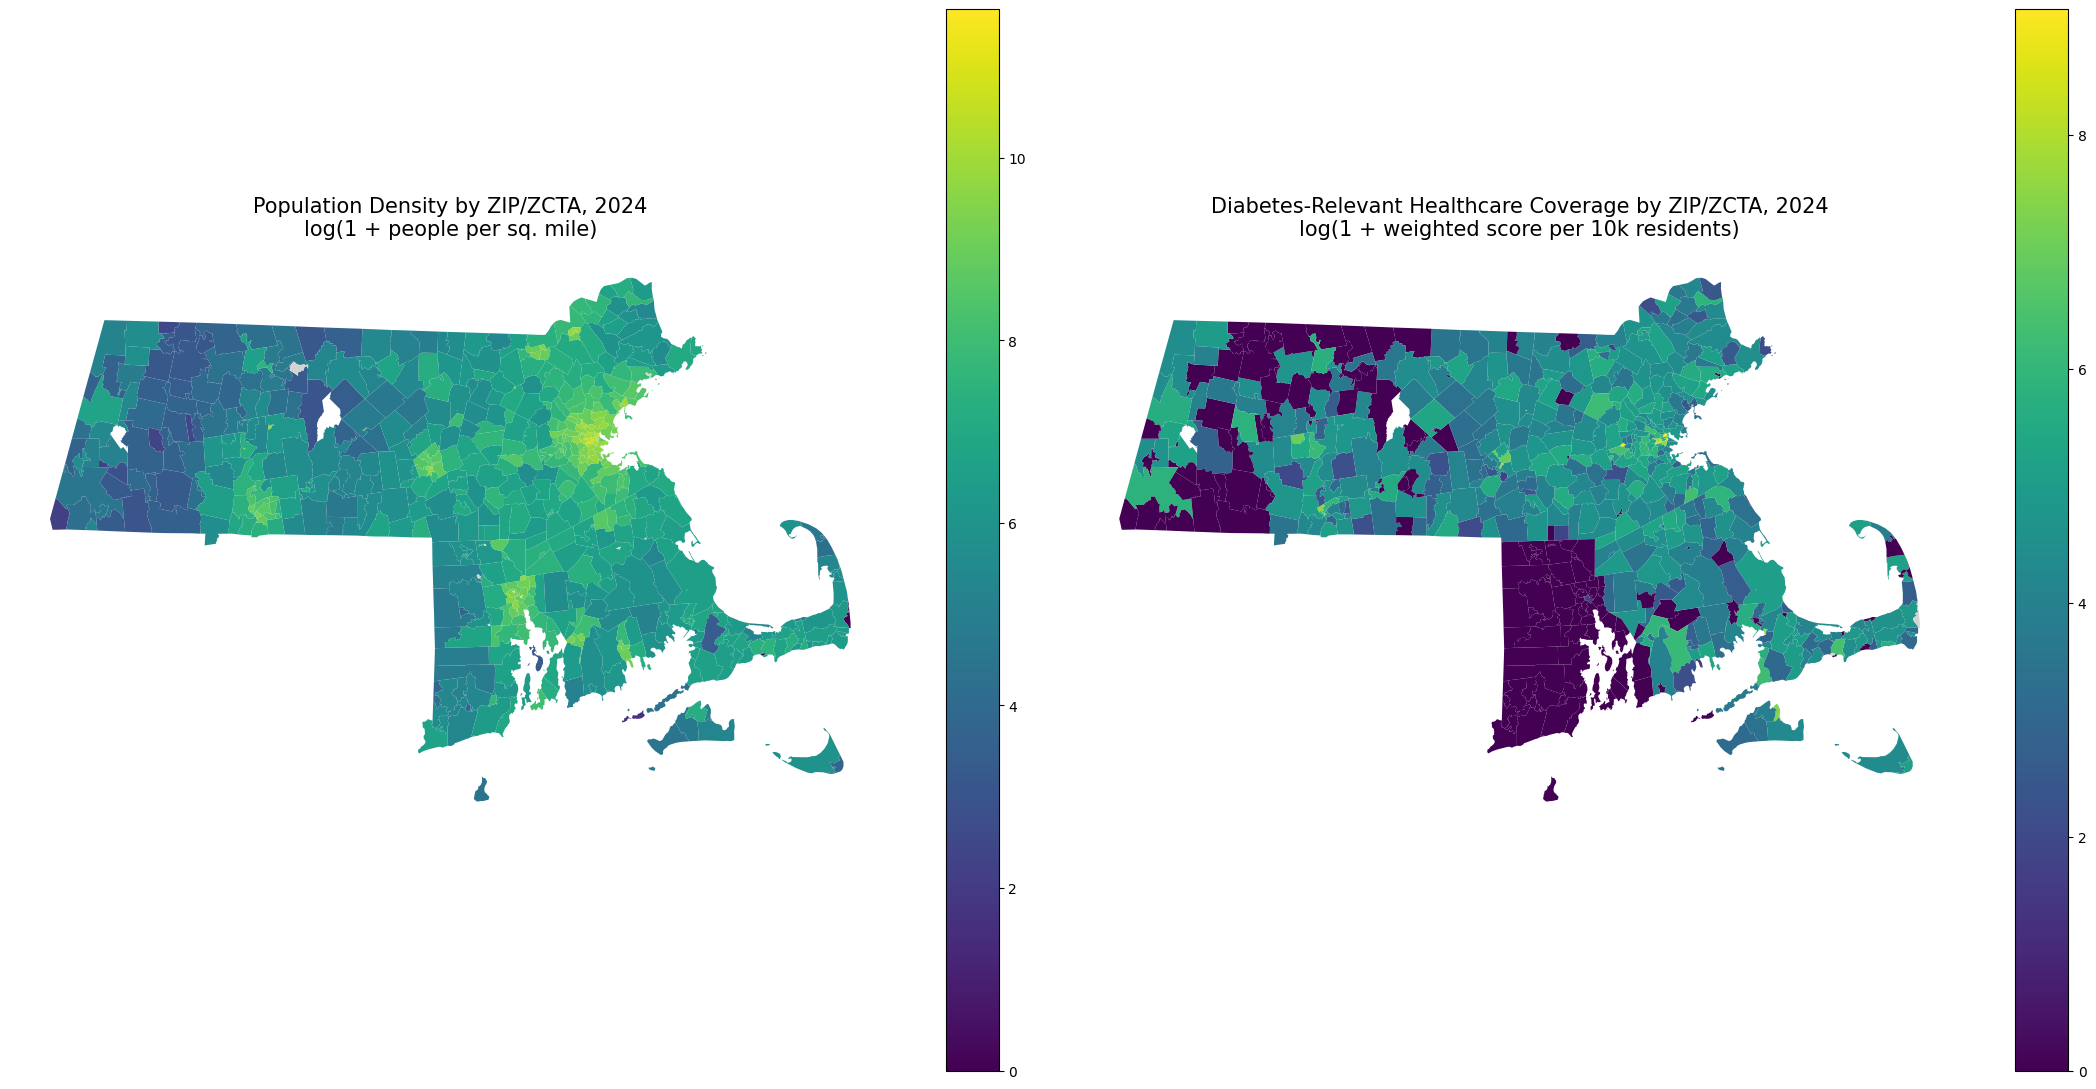

Saved ZIP/ZCTA side-by-side map:
Census_Healthcare_Data/ma_zip_population_density_and_care_coverage_maps_latest_year.png


,zcta,density_per_sq_mile,population_density_log,overall_healthcare_coverage,healthcare_coverage_log
0,01585,188.273055,5.243191,81.081081,4.407708
1,01741,343.001178,5.840645,64.897881,4.188106
2,01033,218.587093,5.391749,8.223684,2.221775
3,01570,1436.270940,7.270501,96.912328,4.584072
4,01608,11008.928571,9.306553,3274.533658,8.094236


In [47]:
# Create and display side-by-side maps

"""
Create side-by-side ZIP/ZCTA maps:
1. Population density, log-scaled
2. Diabetes-relevant healthcare coverage, log-scaled
"""

def create_zip_side_by_side_maps(population_density, provider_density):
    map_df, latest_year = prepare_zip_density_map_data(
        population_density,
        provider_density
    )

    fig, axes = plt.subplots(1, 2, figsize=(22, 11))

    map_df.plot(
        column="population_density_log",
        cmap="viridis",
        legend=True,
        edgecolor="none",
        linewidth=0,
        ax=axes[0],
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    axes[0].set_title(
        f"Population Density by ZIP/ZCTA, {latest_year}\nlog(1 + people per sq. mile)",
        fontsize=15,
        pad=12
    )
    axes[0].axis("off")

    map_df.plot(
        column="healthcare_coverage_log",
        cmap="viridis",
        legend=True,
        edgecolor="none",
        linewidth=0,
        ax=axes[1],
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    axes[1].set_title(
        f"Diabetes-Relevant Healthcare Coverage by ZIP/ZCTA, {latest_year}\nlog(1 + weighted score per 10k residents)",
        fontsize=15,
        pad=12
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(ZIP_SIDE_BY_SIDE_MAP_OUTPUT, dpi=300, bbox_inches="tight")

    display(fig)
    plt.close(fig)

    return map_df


zip_density_maps = create_zip_side_by_side_maps(
    population_density,
    provider_density
)

print("Saved ZIP/ZCTA side-by-side map:")
print(ZIP_SIDE_BY_SIDE_MAP_OUTPUT)

display(
    zip_density_maps[
        [
            "zcta",
            "density_per_sq_mile",
            "population_density_log",
            "overall_healthcare_coverage",
            "healthcare_coverage_log",
        ]
    ].head()
)

## 3 Healthcare Coverage

### 3.1 Healthcare Coverage Data

In [48]:
# Setup and ACS variables

"""
Healthcare insurance coverage pipeline setup.

Outputs:
- ma_insurance_by_zip.csv
- ma_insurance_with_scores.csv
- ma_insurance_average_coverage_score_by_county.csv
- acs_insurance_variable_names.csv
"""

import os
import time
import requests
import pandas as pd

INSURANCE_RAW_OUTPUT = os.path.join(BASE_PATH, "ma_insurance_by_zip.csv")
INSURANCE_SCORED_OUTPUT = os.path.join(BASE_PATH, "ma_insurance_with_scores.csv")
COUNTY_COVERAGE_OUTPUT = os.path.join(BASE_PATH, "ma_insurance_average_coverage_score_by_county.csv")
ACS_INSURANCE_VARIABLE_NAMES_OUTPUT = os.path.join(BASE_PATH, "acs_insurance_variable_names.csv")

ACS_INSURANCE_VARIABLES = {
    "NAME": "Geographic area name",
    "B27010_001E": "Total civilian noninstitutionalized population",

    "B27010_004E": "Male under 6 years with employer-based insurance only",
    "B27010_020E": "Male 6 to 18 years with employer-based insurance only",
    "B27010_036E": "Male 19 to 64 years with employer-based insurance only",
    "B27010_053E": "Female 19 to 64 years with employer-based insurance only",

    "B27010_005E": "Male under 6 years with direct-purchase insurance only",
    "B27010_021E": "Male 6 to 18 years with direct-purchase insurance only",
    "B27010_037E": "Male 19 to 64 years with direct-purchase insurance only",
    "B27010_054E": "Female 19 to 64 years with direct-purchase insurance only",

    "B27010_006E": "Male under 6 years with Medicare coverage only",
    "B27010_022E": "Male 6 to 18 years with Medicare coverage only",
    "B27010_038E": "Male 19 to 64 years with Medicare coverage only",
    "B27010_055E": "Female 19 to 64 years with Medicare coverage only",

    "B27010_007E": "Male under 6 years with Medicaid or means-tested public coverage only",
    "B27010_023E": "Male 6 to 18 years with Medicaid or means-tested public coverage only",
    "B27010_039E": "Male 19 to 64 years with Medicaid or means-tested public coverage only",

    "B27010_017E": "Male under 6 years with no health insurance coverage",
    "B27010_033E": "Male 6 to 18 years with no health insurance coverage",
    "B27010_050E": "Male 19 to 64 years with no health insurance coverage",
    "B27010_066E": "Female 19 to 64 years with no health insurance coverage",
}

ACS_INSURANCE_VARIABLE_NAMES = pd.DataFrame(
    [
        {"acs_code": code, "description": description}
        for code, description in ACS_INSURANCE_VARIABLES.items()
    ]
)

ACS_INSURANCE_VARIABLE_NAMES.to_csv(
    ACS_INSURANCE_VARIABLE_NAMES_OUTPUT,
    index=False
)

In [49]:
# Fetch ACS insurance data

def fetch_insurance_data(year, api_key=None):
    """
    Fetch ACS 5-year insurance coverage data for all ZCTAs for a given year.
    """
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": ",".join(ACS_INSURANCE_VARIABLES.keys()),
        "for": "zip code tabulation area:*"
    }
    if api_key:
        params["key"] = api_key

    try:
        response = requests.get(url, params=params, timeout=90)
    except requests.exceptions.RequestException as exc:
        print(f"Skipping {year}: request failed: {exc}")
        return None

    if response.status_code != 200:
        print(f"Skipping {year}: ACS endpoint unavailable or variable unsupported.")
        print(response.text[:300])
        return None

    try:
        data = response.json()
    except Exception:
        print(f"Skipping {year}: non-JSON response.")
        print(response.text[:300])
        return None

    if not data or len(data) < 2:
        print(f"Skipping {year}: no data returned.")
        return None

    df = pd.DataFrame(data[1:], columns=data[0])

    df = df.rename(
        columns={
            "zip code tabulation area": "zcta",
            "B27010_001E": "total"
        }
    )

    df["year"] = year
    df["zcta"] = df["zcta"].astype(str).str.zfill(5)
    df["zip_code"] = df["zcta"]

    df = df[df["zcta"].str.startswith(MA_ZCTA_PREFIXES)].copy()

    if df.empty:
        print(f"Skipping {year}: no Massachusetts ZCTAs returned.")
        return None

    numeric_cols = [
        col for col in df.columns
        if col.startswith("B27010_")
    ] + ["total"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["employer"] = df[
        ["B27010_004E", "B27010_020E", "B27010_036E", "B27010_053E"]
    ].sum(axis=1)

    df["direct_purchase"] = df[
        ["B27010_005E", "B27010_021E", "B27010_037E", "B27010_054E"]
    ].sum(axis=1)

    df["medicare"] = df[
        ["B27010_006E", "B27010_022E", "B27010_038E", "B27010_055E"]
    ].sum(axis=1)

    df["medicaid"] = df[
        ["B27010_007E", "B27010_023E", "B27010_039E"]
    ].sum(axis=1)

    df["uninsured"] = df[
        ["B27010_017E", "B27010_033E", "B27010_050E", "B27010_066E"]
    ].sum(axis=1)

    return df[
        [
            "year",
            "zip_code",
            "zcta",
            "NAME",
            "total",
            "employer",
            "direct_purchase",
            "medicare",
            "medicaid",
            "uninsured",
        ]
    ]

def build_insurance_dataset(api_key=None):
    """
    Build Massachusetts ZIP/ZCTA-level insurance coverage dataset.
    """
    all_data = []

    for year in range(START_YEAR, END_YEAR + 1):
        print(f"Processing insurance year {year}...")
        df = fetch_insurance_data(year, api_key=api_key)

        if df is not None and not df.empty:
            all_data.append(df)

        time.sleep(0.4)

    if not all_data:
        raise RuntimeError("No ACS insurance data was fetched.")

    df = pd.concat(all_data, ignore_index=True)

    df["zip_code"] = df["zip_code"].astype(str).str.zfill(5)
    df["zcta"] = df["zcta"].astype(str).str.zfill(5)

    return df.sort_values(["zip_code", "year"]).reset_index(drop=True)


In [50]:
# Add insurance metrics and score

def add_insurance_metrics(df):
    """
    Add insurance percentage metrics and diabetes-relevant coverage score.
    """
    df = df.copy()

    denominator = df["total"].replace({0: pd.NA})

    df["employer_pct"] = df["employer"] / denominator
    df["direct_purchase_pct"] = df["direct_purchase"] / denominator
    df["medicare_pct"] = df["medicare"] / denominator
    df["medicaid_pct"] = df["medicaid"] / denominator
    df["uninsured_pct"] = df["uninsured"] / denominator

    df["coverage_score"] = (
        df["employer_pct"] * 1.0
        + df["direct_purchase_pct"] * 0.8
        + df["medicare_pct"] * 0.7
        + df["medicaid_pct"] * 0.4
        - df["uninsured_pct"] * 1.0
    )

    return df

In [51]:
# ZIP/ZCTA to county mapping

def load_zip_county_crosswalk():
    """
    Load Census 2020 ZCTA-to-county relationship data.

    Uses explicit Census columns:
    - geoid_zcta5_20
    - geoid_county_20
    """
    url = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/zcta520/tab20_zcta520_county20_natl.txt"

    crosswalk = pd.read_csv(url, sep="|", dtype=str)
    crosswalk.columns = crosswalk.columns.str.lower().str.strip()

    zcta_col = "geoid_zcta5_20"
    county_col = "geoid_county_20"

    if zcta_col not in crosswalk.columns:
        raise RuntimeError(f"Missing expected column: {zcta_col}")

    if county_col not in crosswalk.columns:
        raise RuntimeError(f"Missing expected column: {county_col}")

    crosswalk["zip_code"] = (
        crosswalk[zcta_col]
        .astype(str)
        .str.extract(r"(\d{5})$")[0]
        .str.zfill(5)
    )

    crosswalk["county_fips"] = (
        crosswalk[county_col]
        .astype(str)
        .str.extract(r"(\d{5})$")[0]
    )

    crosswalk = crosswalk[
        crosswalk["county_fips"].str.startswith("25", na=False)
    ].copy()

    county_names = {
        "25001": "Barnstable County",
        "25003": "Berkshire County",
        "25005": "Bristol County",
        "25007": "Dukes County",
        "25009": "Essex County",
        "25011": "Franklin County",
        "25013": "Hampden County",
        "25015": "Hampshire County",
        "25017": "Middlesex County",
        "25019": "Nantucket County",
        "25021": "Norfolk County",
        "25023": "Plymouth County",
        "25025": "Suffolk County",
        "25027": "Worcester County",
    }

    crosswalk["county_name"] = crosswalk["county_fips"].map(county_names)

    allocation_col = None

    for candidate in [
        "poppt",
        "pop_pct",
        "population_percent",
        "hupt",
        "hu_pct",
        "areapt",
        "area_pct",
    ]:
        if candidate in crosswalk.columns:
            allocation_col = candidate
            break

    if allocation_col is None:
        crosswalk["allocation_factor"] = 1.0
    else:
        crosswalk["allocation_factor"] = pd.to_numeric(
            crosswalk[allocation_col],
            errors="coerce"
        )

    crosswalk = crosswalk[
        crosswalk["zip_code"].notna()
        & crosswalk["county_name"].notna()
    ].copy()

    crosswalk = (
        crosswalk.sort_values(
            ["zip_code", "allocation_factor"],
            ascending=[True, False]
        )
        .drop_duplicates(subset=["zip_code"], keep="first")
    )

    return crosswalk[
        [
            "zip_code",
            "county_fips",
            "county_name",
            "allocation_factor",
        ]
    ].drop_duplicates()


def add_county_to_insurance_scores(df):
    """
    Add county names to ZIP-level insurance scores.
    """
    df = df.copy()

    df["zip_code"] = (
        df["zip_code"]
        .astype(str)
        .str.extract(r"(\d{1,5})")[0]
        .str.zfill(5)
    )

    crosswalk = load_zip_county_crosswalk()

    return df.merge(crosswalk, on="zip_code", how="left")

In [52]:
# County-level coverage table

def build_county_average_coverage_table(df):
    """
    Build average coverage score table by county and year.
    """
    base = df.dropna(subset=["county_name"]).copy()

    county_df = (
        base.groupby(["year", "county_fips", "county_name"], as_index=False)
        .agg(
            average_coverage_score=("coverage_score", "mean"),
            median_coverage_score=("coverage_score", "median"),
            zip_count=("zip_code", "nunique"),
            total_population=("total", "sum"),
            average_employer_pct=("employer_pct", "mean"),
            average_direct_purchase_pct=("direct_purchase_pct", "mean"),
            average_medicare_pct=("medicare_pct", "mean"),
            average_medicaid_pct=("medicaid_pct", "mean"),
            average_uninsured_pct=("uninsured_pct", "mean"),
        )
    )

    weighted_rows = []

    for keys, group in base.groupby(["year", "county_fips", "county_name"]):
        year, county_fips, county_name = keys

        valid = group.dropna(subset=["coverage_score", "total"]).copy()
        valid = valid[valid["total"] > 0]

        if valid.empty:
            weighted_score = pd.NA
        else:
            weighted_score = (
                valid["coverage_score"] * valid["total"]
            ).sum() / valid["total"].sum()

        weighted_rows.append(
            {
                "year": year,
                "county_fips": county_fips,
                "county_name": county_name,
                "population_weighted_coverage_score": weighted_score,
            }
        )

    weighted_df = pd.DataFrame(weighted_rows)

    county_df = county_df.merge(
        weighted_df,
        on=["year", "county_fips", "county_name"],
        how="left"
    )

    county_df = county_df[
        [
            "year",
            "county_fips",
            "county_name",
            "average_coverage_score",
            "population_weighted_coverage_score",
            "median_coverage_score",
            "zip_count",
            "total_population",
            "average_employer_pct",
            "average_direct_purchase_pct",
            "average_medicare_pct",
            "average_medicaid_pct",
            "average_uninsured_pct",
        ]
    ]

    return county_df.sort_values(
        ["year", "county_name"]
    ).reset_index(drop=True)

In [53]:
# Run pipeline

insurance_raw = build_insurance_dataset(api_key=CENSUS_API_KEY)
insurance_scored = add_insurance_metrics(insurance_raw)
insurance_scored = add_county_to_insurance_scores(insurance_scored)

county_coverage_scores = build_county_average_coverage_table(insurance_scored)

insurance_raw.to_csv(INSURANCE_RAW_OUTPUT, index=False)
insurance_scored.to_csv(INSURANCE_SCORED_OUTPUT, index=False)
county_coverage_scores.to_csv(COUNTY_COVERAGE_OUTPUT, index=False)

print("Saved files:")
print(INSURANCE_RAW_OUTPUT)
print(INSURANCE_SCORED_OUTPUT)
print(COUNTY_COVERAGE_OUTPUT)
print(ACS_INSURANCE_VARIABLE_NAMES_OUTPUT)

print("\nYear range downloaded:")
print(insurance_raw["year"].min(), "to", insurance_raw["year"].max())

display(insurance_scored.head())
display(county_coverage_scores.head())

Processing insurance year 2011...
Skipping 2011: ACS endpoint unavailable or variable unsupported.
error: unknown variable 'B27010_001E'
Processing insurance year 2012...
Skipping 2012: ACS endpoint unavailable or variable unsupported.
error: unknown variable 'B27010_001E'
Processing insurance year 2013...
Processing insurance year 2014...
Processing insurance year 2015...
Processing insurance year 2016...
Processing insurance year 2017...
Processing insurance year 2018...
Processing insurance year 2019...
Processing insurance year 2020...
Processing insurance year 2021...
Processing insurance year 2022...
Processing insurance year 2023...
Processing insurance year 2024...
Processing insurance year 2025...
Skipping 2025: ACS endpoint unavailable or variable unsupported.
<!doctype html><html lang="en"><head><title>HTTP Status 404 ? Not Found</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} h1 {font-size:22px;

,year,zip_code,zcta,NAME,total,employer,direct_purchase,medicare,medicaid,uninsured,employer_pct,direct_purchase_pct,medicare_pct,medicaid_pct,uninsured_pct,coverage_score,county_fips,county_name,allocation_factor
0,2013,01001,01001,ZCTA5 01001,16643,9357,570,447,1942,726,0.562218,0.034249,0.026858,0.116686,0.043622,0.61147,25013,Hampden County,1.0
1,2014,01001,01001,ZCTA5 01001,16526,8967,761,513,1992,704,0.5426,0.046049,0.031042,0.120537,0.0426,0.606783,25013,Hampden County,1.0
2,2015,01001,01001,ZCTA5 01001,16824,8679,560,433,2595,718,0.51587,0.033286,0.025737,0.154244,0.042677,0.579535,25013,Hampden County,1.0
3,2016,01001,01001,ZCTA5 01001,16841,8052,513,488,2803,607,0.478119,0.030461,0.028977,0.166439,0.036043,0.553304,25013,Hampden County,1.0
4,2017,01001,01001,ZCTA5 01001,16969,7692,747,586,2871,529,0.453297,0.044021,0.034534,0.169191,0.031174,0.54919,25013,Hampden County,1.0


,year,county_fips,county_name,average_coverage_score,population_weighted_coverage_score,median_coverage_score,zip_count,total_population,average_employer_pct,average_direct_purchase_pct,average_medicare_pct,average_medicaid_pct,average_uninsured_pct
0,2013,25001,Barnstable County,0.509507,0.506682,0.496333,48,214349,0.429333,0.067987,0.04579,0.09465,0.044129
1,2013,25003,Berkshire County,0.596124,0.582334,0.585797,36,131071,0.501584,0.064035,0.044627,0.115577,0.034158
2,2013,25005,Bristol County,0.620934,0.600454,0.648529,36,570193,0.537872,0.054268,0.035793,0.136942,0.040184
3,2013,25007,Dukes County,0.555237,0.559541,0.552948,6,16607,0.462726,0.104055,0.033405,0.110813,0.058442
4,2013,25009,Essex County,0.646302,0.623693,0.688061,45,801770,0.562156,0.051178,0.036674,0.128849,0.034008


### 3.2 Healthcare Coverage Map

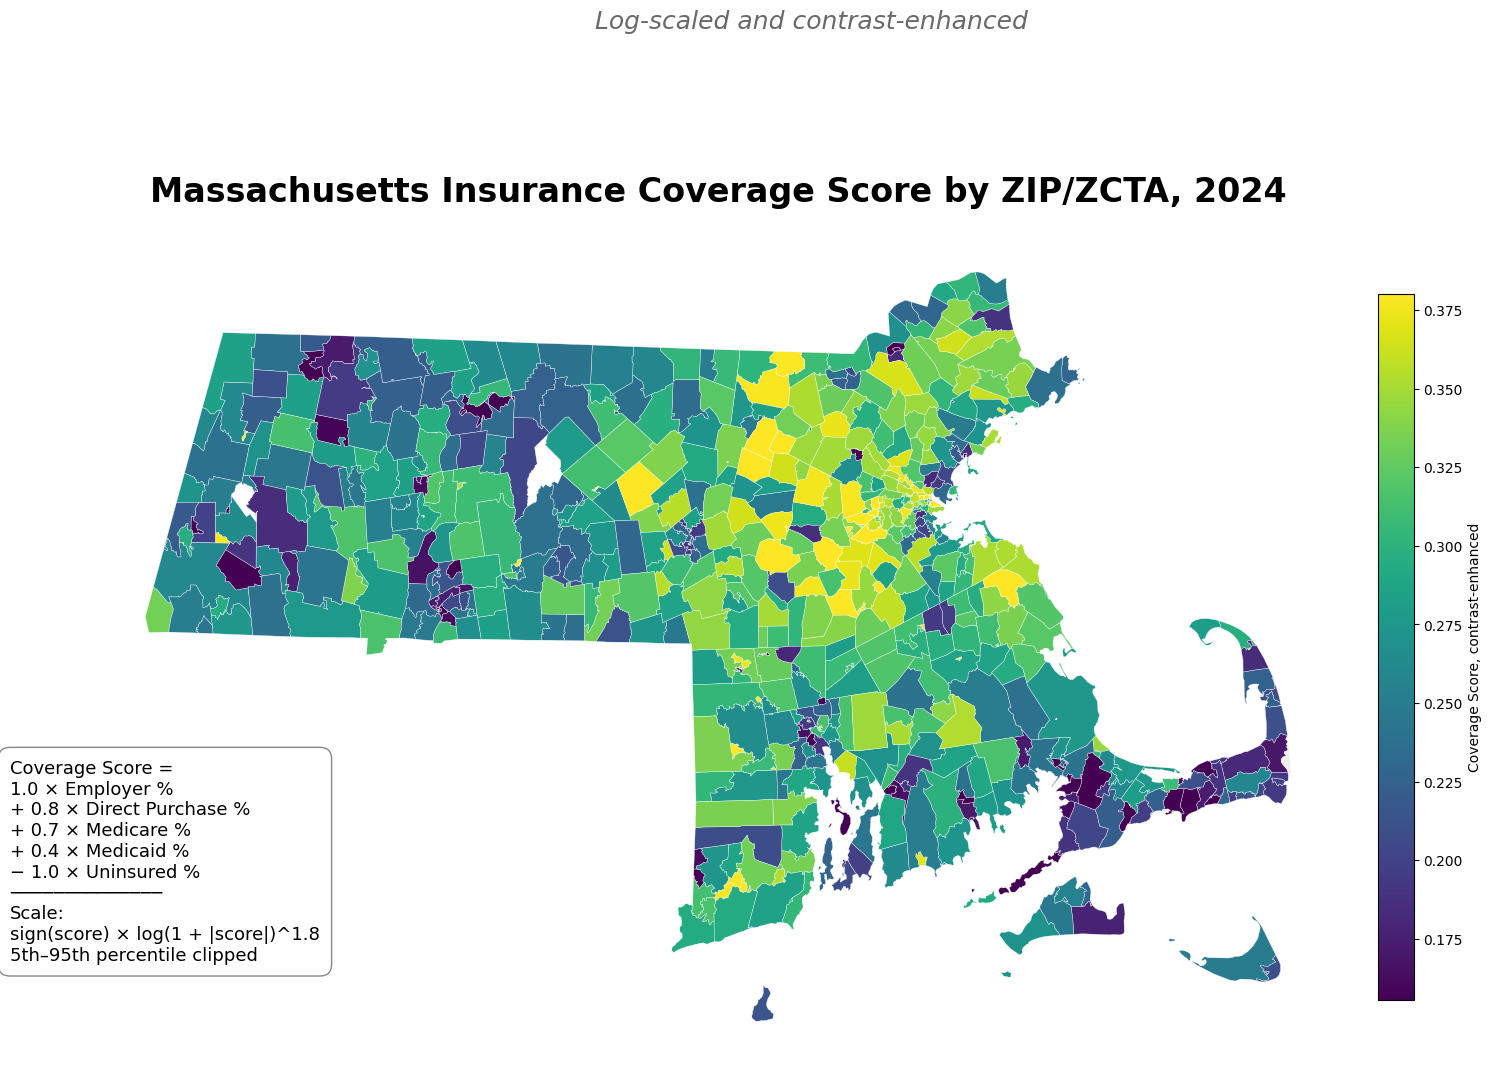

Saved infographic-style insurance coverage map:
Census_Healthcare_Data/ma_insurance_coverage_score_infographic_zip.png


In [54]:
"""
High-contrast infographic-style Massachusetts insurance coverage map by ZIP/ZCTA.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from IPython.display import display

INFOGRAPHIC_INSURANCE_MAP_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_insurance_coverage_score_infographic_zip.png"
)

latest_year = int(pd.to_numeric(insurance_scored["year"], errors="coerce").max())

insurance_latest = insurance_scored[
    insurance_scored["year"] == latest_year
].copy()

insurance_latest["zip_code"] = (
    insurance_latest["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zip_code"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

ma_zctas = zctas[
    zctas["zip_code"].str.startswith(("01", "02"), na=False)
].copy()

map_df = ma_zctas.merge(
    insurance_latest[
        [
            "zip_code",
            "coverage_score",
            "employer_pct",
            "direct_purchase_pct",
            "medicare_pct",
            "medicaid_pct",
            "uninsured_pct",
        ]
    ],
    on="zip_code",
    how="left"
)

score = pd.to_numeric(map_df["coverage_score"], errors="coerce").astype(float)

map_df["coverage_score_scaled"] = (
    np.sign(score)
    * np.power(np.log1p(np.abs(score)), 1.8)
)

values = map_df["coverage_score_scaled"].dropna()

vmin = values.quantile(0.05)
vmax = values.quantile(0.95)

if vmin < 0 and vmax > 0:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = "RdYlGn"
else:
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = "viridis"

fig, ax = plt.subplots(figsize=(18, 12))

map_df.plot(
    column="coverage_score_scaled",
    cmap=cmap,
    norm=norm,
    legend=True,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.78,
        "pad": 0.02,
        "label": "Coverage Score, contrast-enhanced"
    }
)

ax.set_title(
    f"Massachusetts Insurance Coverage Score by ZIP/ZCTA, {latest_year}",
    fontsize=24,
    fontweight="bold",
    pad=24
)

ax.text(
    0.5,
    0.965,
    "Log-scaled and contrast-enhanced",
    transform=fig.transFigure,
    ha="center",
    fontsize=18,
    style="italic",
    color="dimgray"
)

ax.text(
    0.055,
    0.185,
    "Coverage Score =\n"
    "1.0 × Employer %\n"
    "+ 0.8 × Direct Purchase %\n"
    "+ 0.7 × Medicare %\n"
    "+ 0.4 × Medicaid %\n"
    "− 1.0 × Uninsured %\n"
    "──────────────\n"
    "Scale:\n"
    "sign(score) × log(1 + |score|)^1.8\n"
    "5th–95th percentile clipped",
    transform=fig.transFigure,
    fontsize=13,
    va="bottom",
    bbox={
        "boxstyle": "round,pad=0.65",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.95
    }
)

ax.axis("off")

plt.tight_layout(rect=[0.02, 0.06, 0.95, 0.94])
plt.savefig(INFOGRAPHIC_INSURANCE_MAP_OUTPUT, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved infographic-style insurance coverage map:")
print(INFOGRAPHIC_INSURANCE_MAP_OUTPUT)

# 4 High-risk events per zip code

## 4.1 High-risk events data

In [55]:
"""
Prepare high-risk events per patient by ZIP/ZCTA.

Inputs:
- diabetic_patients_new.csv
- features_new.csv

Output DataFrame:
- events_by_zip
"""

!pip install -q pandas

import os
import glob
import numpy as np
import pandas as pd
from IPython.display import display

SEARCH_ROOTS = [
    "/content",
    "/content/drive/MyDrive",
]

def find_file(filename_stem):
    matches = []

    for root in SEARCH_ROOTS:
        matches.extend(
            glob.glob(
                os.path.join(root, "**", f"{filename_stem}.csv"),
                recursive=True
            )
        )

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename_stem}.csv. Mount Google Drive and check the file name."
        )

    return matches[0]


def detect_column(df, candidates):
    lower_map = {col.lower().strip(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    for col in df.columns:
        col_lower = col.lower()
        if any(candidate.lower() in col_lower for candidate in candidates):
            return col

    raise RuntimeError(f"Could not detect column from candidates: {candidates}")


PATIENT_FILE = find_file("diabetic_patients_new")
FEATURES_FILE = find_file("features_new")

print("Patient file:", PATIENT_FILE)
print("Features file:", FEATURES_FILE)

patients = pd.read_csv(PATIENT_FILE)
features = pd.read_csv(FEATURES_FILE)

patient_id_col = detect_column(
    patients,
    ["patient_id", "patient id", "id", "PatientID", "PATIENT_ID"]
)

address_col = detect_column(
    patients,
    ["address", "street", "patient_address", "residence", "location"]
)

feature_patient_id_col = detect_column(
    features,
    ["patient_id", "patient id", "id", "PatientID", "PATIENT_ID"]
)

# Column D = fourth column
high_risk_col = features.columns[3]

print("Detected patient ID column:", patient_id_col)
print("Detected address column:", address_col)
print("Detected features patient ID column:", feature_patient_id_col)
print("Using features column D as high-risk value:", high_risk_col)

patients_clean = patients[[patient_id_col, address_col]].copy()

patients_clean = patients_clean.rename(
    columns={
        patient_id_col: "patient_id",
        address_col: "address"
    }
)

patients_clean["patient_id"] = patients_clean["patient_id"].astype(str)

patients_clean["zip_code"] = (
    patients_clean["address"]
    .astype(str)
    .str.extract(r"(\d{5})(?:-\d{4})?")[0]
)

patients_clean = patients_clean[patients_clean["zip_code"].notna()].copy()
patients_clean["zip_code"] = patients_clean["zip_code"].astype(str).str.zfill(5)

patients_clean = patients_clean[
    patients_clean["zip_code"].str.startswith(("01", "02"), na=False)
].copy()

features_clean = features[[feature_patient_id_col, high_risk_col]].copy()

features_clean = features_clean.rename(
    columns={
        feature_patient_id_col: "patient_id",
        high_risk_col: "high_risk_value"
    }
)

features_clean["patient_id"] = features_clean["patient_id"].astype(str)

features_clean["high_risk_value"] = pd.to_numeric(
    features_clean["high_risk_value"],
    errors="coerce"
).fillna(0)

events_by_patient = (
    features_clean
    .groupby("patient_id", as_index=False)
    .agg(high_risk_events=("high_risk_value", "sum"))
)

patient_events = patients_clean.merge(
    events_by_patient,
    on="patient_id",
    how="left"
)

patient_events["high_risk_events"] = patient_events["high_risk_events"].fillna(0)

events_by_zip = (
    patient_events
    .groupby("zip_code", as_index=False)
    .agg(
        patient_count=("patient_id", "nunique"),
        high_risk_events=("high_risk_events", "sum")
    )
)

events_by_zip["high_risk_events_per_patient"] = (
    events_by_zip["high_risk_events"]
    / events_by_zip["patient_count"].replace({0: np.nan})
)

events_by_zip["high_risk_events_per_patient_log"] = np.log1p(
    events_by_zip["high_risk_events_per_patient"]
)

print("Prepared ZIP-level high-risk event data:")
display(events_by_zip.head())

Patient file: /content/drive/MyDrive/MASAID/EHR_TechnicalDifficulties_Share/EXTENSIONS/diabetic_patients_new.csv
Features file: /content/drive/MyDrive/MASAID/EHR_TechnicalDifficulties_Share/EXTENSIONS/features_new.csv
Detected patient ID column: ID
Detected address column: ADDRESS
Detected features patient ID column: patient_id
Using features column D as high-risk value: will_have_high_risk_event_next_30d
Prepared ZIP-level high-risk event data:


,zip_code,patient_count,high_risk_events,high_risk_events_per_patient,high_risk_events_per_patient_log
0,01001,8,8,1.000000,0.693147
1,01002,4,6,1.500000,0.916291
2,01003,2,2,1.000000,0.693147
3,01004,6,4,0.666667,0.510826
4,01005,3,2,0.666667,0.510826


## 4.2 High-risk events map per patient

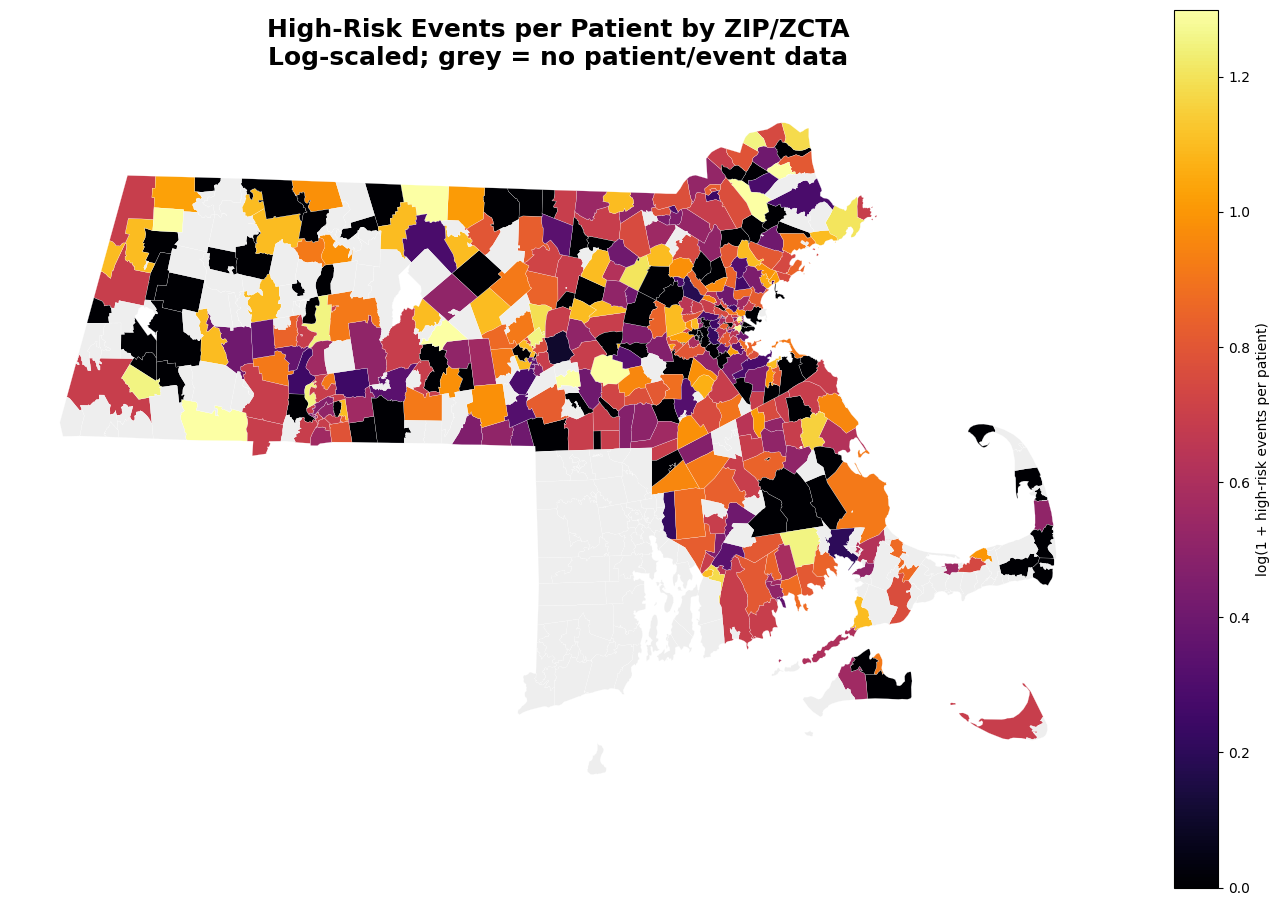

Saved high-risk event map:
Census_Healthcare_Data/ma_high_risk_events_per_patient_by_zip_log_scaled.png
ZIP/ZCTAs with patient/event data: 402
ZIP/ZCTAs with no patient/event data: 218


In [56]:
"""
Map high-risk events per patient by ZIP/ZCTA.
Grey areas are filled as 0 high-risk events.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

HIGH_RISK_EVENT_MAP_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_high_risk_events_per_patient_by_zip_log_scaled.png"
)

zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zip_code"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

ma_zctas = zctas[
    zctas["zip_code"].str.startswith(("01", "02"), na=False)
].copy()

map_df = ma_zctas.merge(
    events_by_zip,
    on="zip_code",
    how="left"
)

map_df["high_risk_events_per_patient_log"] = np.log1p(
    map_df["high_risk_events_per_patient"]
)

values = map_df["high_risk_events_per_patient_log"].dropna()

vmin = values.quantile(0.02)
vmax = values.quantile(0.98)

fig, ax = plt.subplots(figsize=(14, 12))

map_df.plot(
    column="high_risk_events_per_patient_log",
    cmap="inferno",
    legend=True,
    norm=Normalize(vmin=vmin, vmax=vmax),
    edgecolor="white",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.75,
        "label": "log(1 + high-risk events per patient)"
    }
)

ax.set_title(
    "High-Risk Events per Patient by ZIP/ZCTA\nLog-scaled; grey = no patient/event data",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.axis("off")

plt.tight_layout()
plt.savefig(HIGH_RISK_EVENT_MAP_OUTPUT, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved high-risk event map:")
print(HIGH_RISK_EVENT_MAP_OUTPUT)

print("ZIP/ZCTAs with patient/event data:", map_df["patient_count"].notna().sum())
print("ZIP/ZCTAs with no patient/event data:", map_df["patient_count"].isna().sum())

In [57]:
population_latest = (
    population_density
    .sort_values("year")
    .groupby("zip_code", as_index=False)
    .last()
)

provider_latest = (
    provider_density
    .sort_values("year")
    .drop_duplicates("zip_code", keep="last")
)

'''
provider_latest = (
    provider_density
    .groupby("zip_code", as_index=False)
    .agg({
        "overall_healthcare_coverage": "mean"
    })
)
'''

df = events_by_zip.merge(
    population_latest[["zip_code", "density_per_sq_mile"]],
    on="zip_code",
    how="left"
)

df = df.merge(
    provider_latest[["zip_code", "overall_healthcare_coverage"]],
    on="zip_code",
    how="left"
)

## 4.3 High-risk event map by pop density


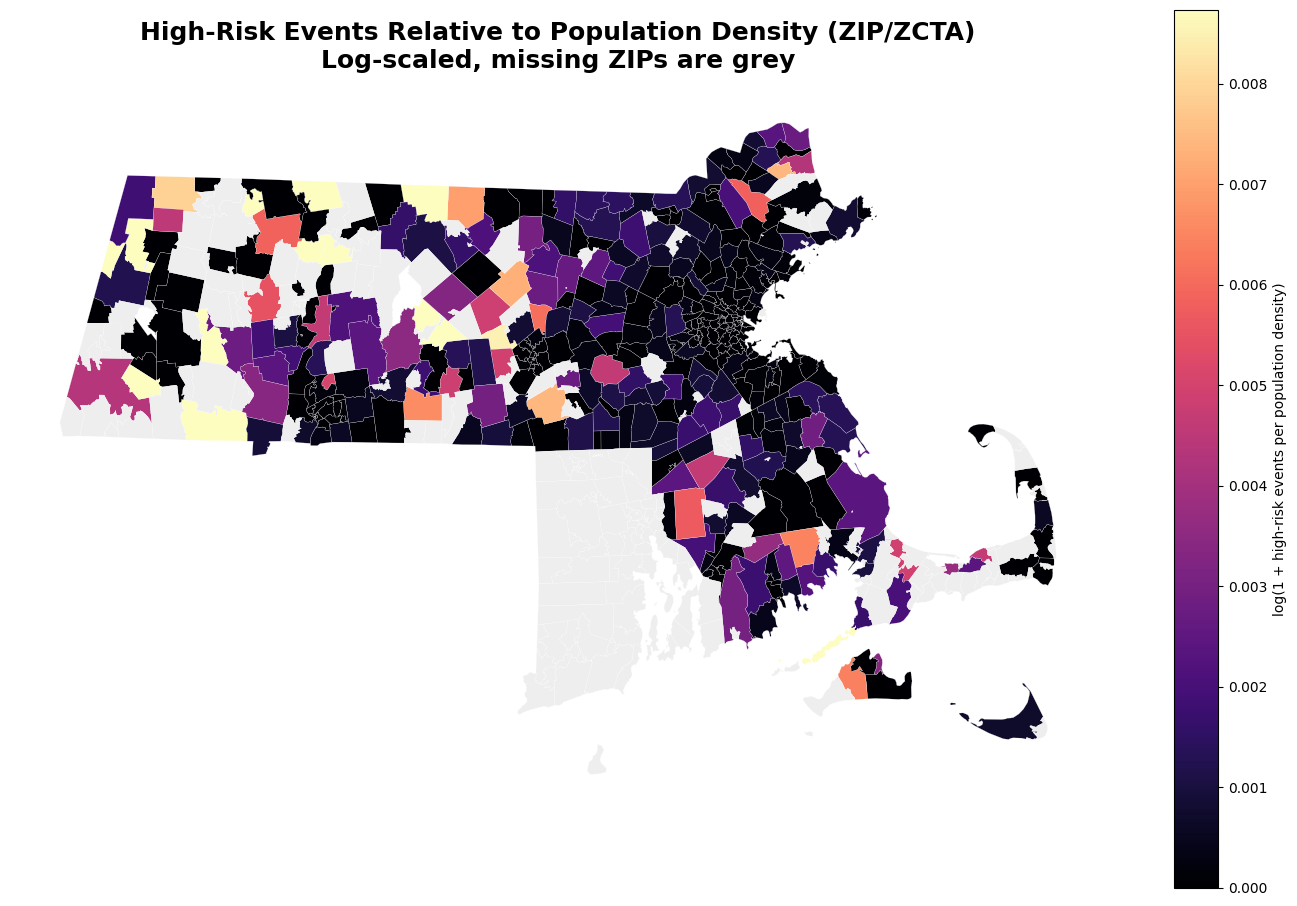

Saved map:
Census_Healthcare_Data/ma_high_risk_events_per_population_density.png
ZIP/ZCTAs with patient/event data: 402
ZIP/ZCTAs zeros not filled: 0


In [58]:
"""
Map: High-risk events relative to population density (ZIP/ZCTA level).
Missing ZIPs are filled as 0 events.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

OUTPUT_PATH = os.path.join(
    BASE_PATH,
    "ma_high_risk_events_per_population_density.png"
)

population = pd.read_csv(POPULATION_OUTPUT_FILE)

population["zip_code"] = (
    population["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

population_latest_year = int(pd.to_numeric(population["year"], errors="coerce").max())

population_latest = population[
    population["year"] == population_latest_year
].copy()

events_by_zip["zip_code"] = (
    events_by_zip["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

df = population_latest[[
    "zip_code",
    "density_per_sq_mile"
]].merge(
    events_by_zip[[
        "zip_code",
        "patient_count",
        "high_risk_events"
    ]],
    on="zip_code",
    how="left"
)

df["patient_count"] = df["patient_count"]
df["high_risk_events"] = df["high_risk_events"]

density = pd.to_numeric(
    df["density_per_sq_mile"],
    errors="coerce"
).replace({0: np.nan})

df["events_per_density"] = df["high_risk_events"] / density
df["events_per_density"] = df["events_per_density"]

df["events_per_density_log"] = np.log1p(df["events_per_density"])

zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zip_code"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

ma_zctas = zctas[
    zctas["zip_code"].str.startswith(("01", "02"), na=False)
].copy()

map_df = ma_zctas.merge(df, on="zip_code", how="left")

fill_cols = [
    "patient_count",
    "high_risk_events",
    "events_per_density",
    "events_per_density_log",
]

for col in fill_cols:
    map_df[col] = map_df[col]

map_df["events_per_density_log"] = np.power(
    map_df["events_per_density_log"],
    1.4
)

values = map_df["events_per_density_log"].dropna()

vmin = values.quantile(0.03)
vmax = values.quantile(0.97)

fig, ax = plt.subplots(figsize=(14, 12))

map_df.plot(
    column="events_per_density_log",
    cmap="magma",
    norm=Normalize(vmin=vmin, vmax=vmax),
    legend=True,
    edgecolor="white",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.75,
        "label": "log(1 + high-risk events per population density)"
    }
)

ax.set_title(
    "High-Risk Events Relative to Population Density (ZIP/ZCTA)\n"
    "Log-scaled, missing ZIPs are grey",
    fontsize=18,
    fontweight="bold",
    pad=16
)

ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved map:")
print(OUTPUT_PATH)
print("ZIP/ZCTAs with patient/event data:", (map_df["patient_count"] > 0).sum())
print("ZIP/ZCTAs zeros not filled:", (map_df["patient_count"] == 0).sum())

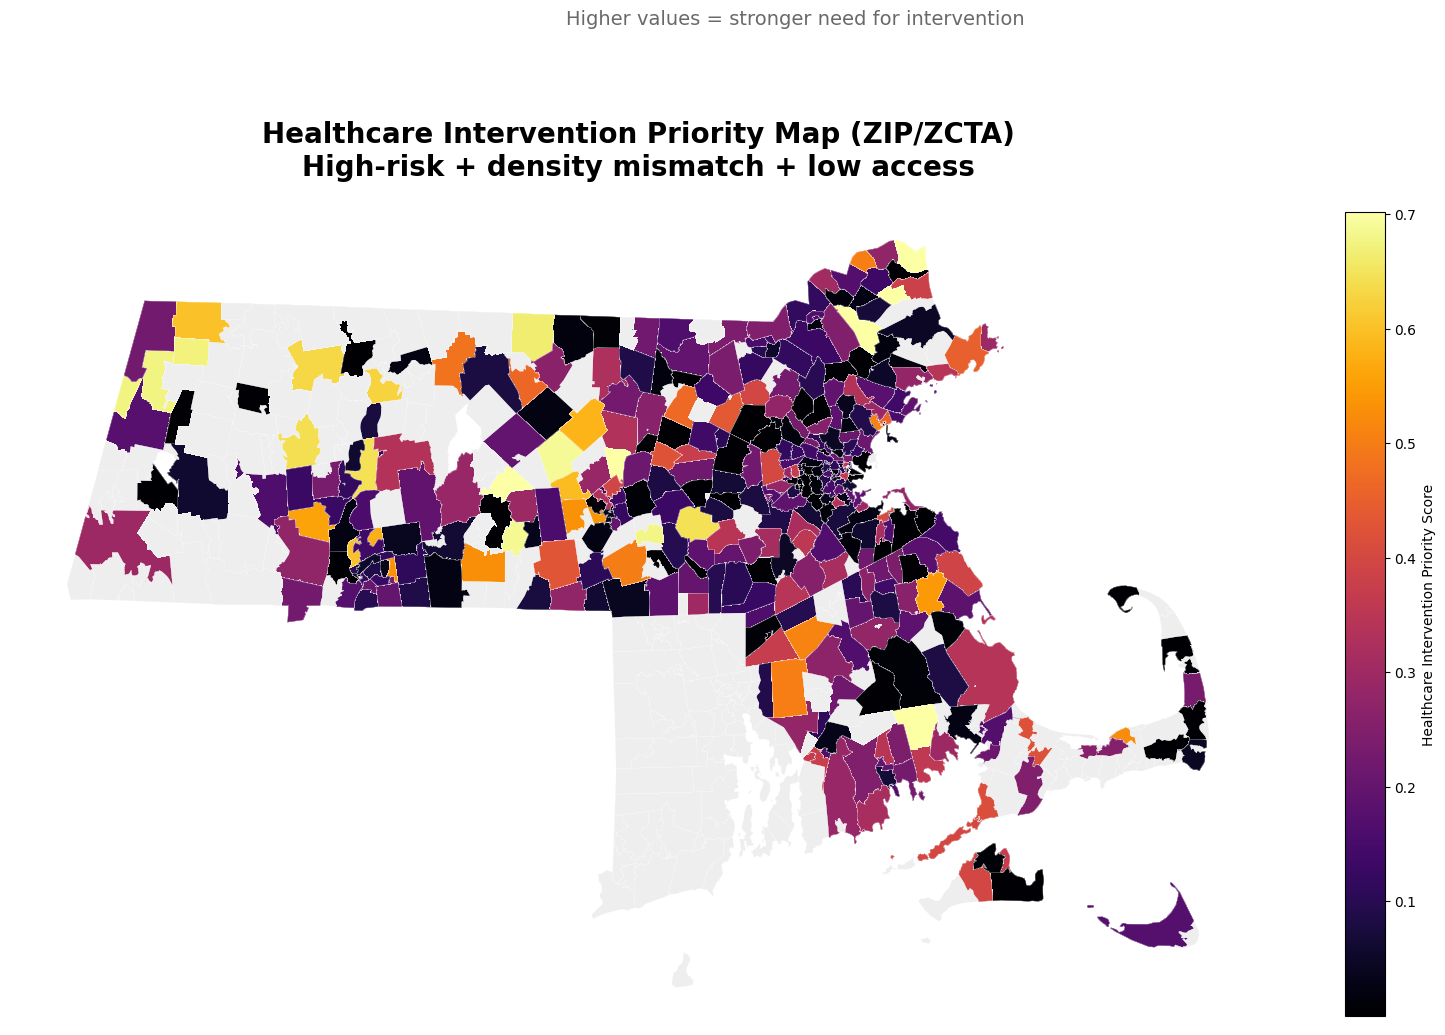

Saved priority map:
Census_Healthcare_Data/ma_healthcare_priority_score_map.png

Top 20 priority ZIP codes:


,zip_code,priority_score,high_risk_events_per_patient,risk_per_density,overall_healthcare_coverage
40634,01922,1.0,2.75,0.030586,11.594203
40477,01922,1.0,2.75,0.034884,10.180708
40478,01922,1.0,2.75,0.034884,10.452051
40480,01922,1.0,2.75,0.034884,11.594203
40479,01922,1.0,2.75,0.034884,10.551306
40490,01922,1.0,2.75,0.039835,10.64396
40488,01922,1.0,2.75,0.039835,12.210012
40550,01922,1.0,2.75,0.032211,11.594203
40547,01922,1.0,2.75,0.032211,10.180708
40548,01922,1.0,2.75,0.032211,10.452051


In [59]:
"""
Priority score map: combines risk, density mismatch, and provider access.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

OUTPUT_PATH = os.path.join(
    BASE_PATH,
    "ma_healthcare_priority_score_map.png"
)

# ---------- INPUTS ----------
# You already created these earlier
# events_by_zip
# provider_density
# population (POPULATION_OUTPUT_FILE)

population = pd.read_csv(POPULATION_OUTPUT_FILE)

population["zip_code"] = (
    population["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

provider_density["zip_code"] = provider_density["zip_code"].astype(str).str.zfill(5)

# ---------- MERGE ----------
df = events_by_zip.merge(
    population[["zip_code", "density_per_sq_mile"]],
    on="zip_code",
    how="left"
)

df = df.merge(
    provider_density[
        ["zip_code", "overall_healthcare_coverage"]
    ],
    on="zip_code",
    how="left"
)

# ---------- METRICS ----------
density = pd.to_numeric(df["density_per_sq_mile"], errors="coerce").replace({0: np.nan})
coverage = pd.to_numeric(df["overall_healthcare_coverage"], errors="coerce").replace({0: np.nan})

# 1. Clinical risk
df["risk_per_patient"] = df["high_risk_events_per_patient"]

# 2. Structural mismatch
df["risk_per_density"] = df["high_risk_events"] / density

# 3. Access (inverse → lower coverage = worse)
df["inverse_coverage"] = 1 / coverage

# ---------- NORMALIZATION ----------
def robust_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    s = (s - s.quantile(0.05)) / (s.quantile(0.95) - s.quantile(0.05))
    return s.clip(0, 1)

df["risk_scaled"] = robust_scale(df["risk_per_patient"])
df["density_scaled"] = robust_scale(df["risk_per_density"])
df["access_scaled"] = robust_scale(df["inverse_coverage"])

# ---------- PRIORITY SCORE ----------
# weights = importance
df["priority_score"] = (
    0.5 * df["risk_scaled"] +
    0.3 * df["density_scaled"] +
    0.2 * df["access_scaled"]
)

# amplify contrast
df["priority_score"] = np.power(df["priority_score"], 1.5)

# ---------- MAP ----------
zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zip_code"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

ma_zctas = zctas[
    zctas["zip_code"].str.startswith(("01", "02"), na=False)
].copy()

map_df = ma_zctas.merge(df, on="zip_code", how="left")

values = map_df["priority_score"].dropna()
vmin = values.quantile(0.02)
vmax = values.quantile(0.98)

fig, ax = plt.subplots(figsize=(16, 12))

map_df.plot(
    column="priority_score",
    cmap="inferno",
    norm=Normalize(vmin=vmin, vmax=vmax),
    legend=True,
    edgecolor="white",
    linewidth=0.15,
    ax=ax,
    missing_kwds={
        "color": "#eeeeee",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.75,
        "label": "Healthcare Intervention Priority Score"
    }
)

ax.set_title(
    "Healthcare Intervention Priority Map (ZIP/ZCTA)\n"
    "High-risk + density mismatch + low access",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.text(
    0.5,
    0.95,
    "Higher values = stronger need for intervention",
    transform=fig.transFigure,
    ha="center",
    fontsize=14,
    color="dimgray"
)

ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved priority map:")
print(OUTPUT_PATH)

# ---------- OPTIONAL: TOP TARGET ZIPS ----------
top_targets = df.sort_values("priority_score", ascending=False).head(20)

print("\nTop 20 priority ZIP codes:")
display(top_targets[[
    "zip_code",
    "priority_score",
    "high_risk_events_per_patient",
    "risk_per_density",
    "overall_healthcare_coverage"
]])

# 5 Map Summaries

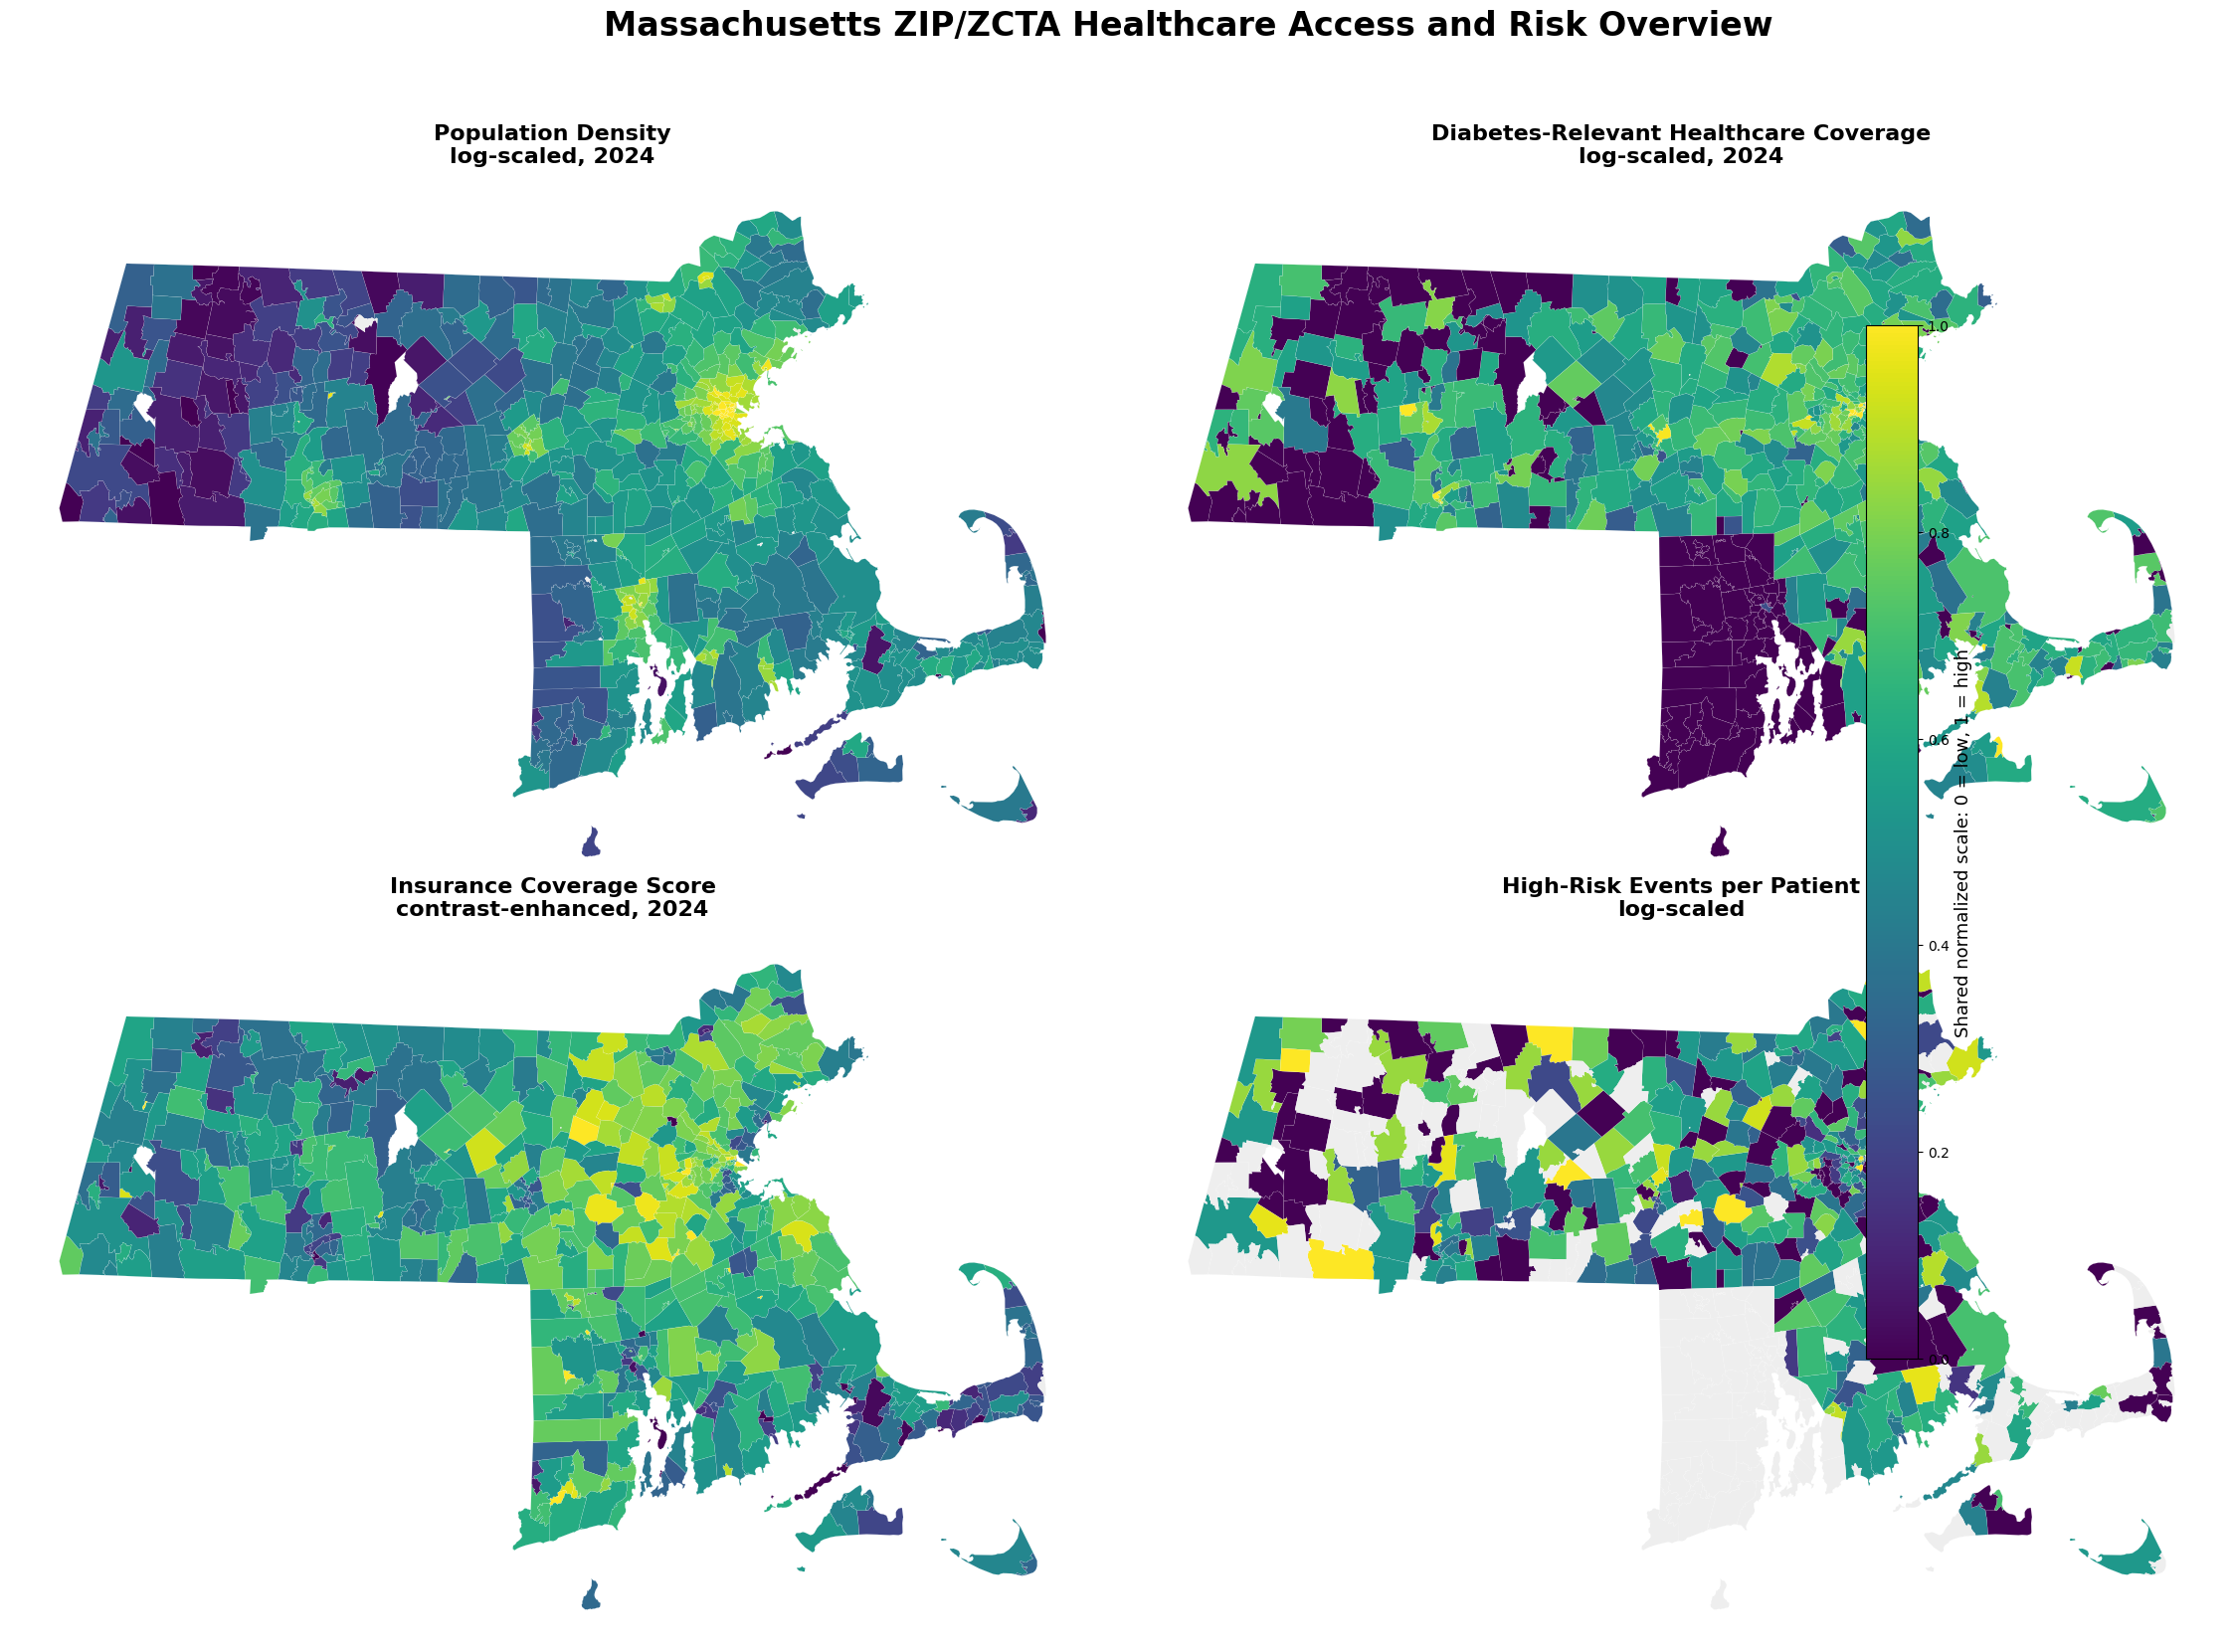

Saved 2x2 map grid:
Census_Healthcare_Data/ma_2x2_population_access_insurance_risk_maps.png
Missing values by map:
population_density_norm      11
healthcare_coverage_norm      7
insurance_coverage_norm       8
high_risk_events_norm       218
dtype: int64


In [60]:
"""
2x2 ZIP/ZCTA map grid using one shared color scale.

Maps:
1. Population density
2. Diabetes-relevant healthcare coverage
3. Insurance coverage score
4. High-risk events per patient

All metrics are transformed and then normalized to 0–1 using robust percentile scaling.
"""

!pip install -q geopandas matplotlib pyogrio

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

FOUR_MAP_OUTPUT = os.path.join(
    BASE_PATH,
    "ma_2x2_population_access_insurance_risk_maps.png"
)

# ---------- Helper ----------

def normalize_robust(series, lower=0.02, upper=0.98):
    s = pd.to_numeric(series, errors="coerce")

    # keep NaNs untouched
    valid = s.dropna()
    if len(valid) == 0:
        return s  # all NaN → stay grey

    lo = valid.quantile(lower)
    hi = valid.quantile(upper)

    if hi == lo:
        return s  # avoid division crash

    scaled = (s - lo) / (hi - lo)

    return scaled.clip(0, 1)


# ---------- Standardize population ----------

population_df = population_density.copy()

population_df["zip_code"] = (
    population_df["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

population_latest_year = int(pd.to_numeric(population_df["year"], errors="coerce").max())

population_latest = (
    population_df[population_df["year"] == population_latest_year]
    .drop_duplicates(subset=["zip_code"])
    .copy()
)

population_latest["population_density_log"] = np.log1p(
    pd.to_numeric(population_latest["density_per_sq_mile"], errors="coerce")
)


# ---------- Standardize provider density ----------

provider_df = provider_density.copy()

provider_df["zip_code"] = (
    provider_df["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

provider_latest_year = int(pd.to_numeric(provider_df["year"], errors="coerce").max())

provider_latest = (
    provider_df[provider_df["year"] == provider_latest_year]
    .drop_duplicates(subset=["zip_code"])
    .copy()
)

provider_latest["healthcare_coverage_log"] = np.log1p(
    pd.to_numeric(provider_latest["overall_healthcare_coverage"], errors="coerce")
)


# ---------- Standardize insurance ----------

insurance_df = insurance_scored.copy()

insurance_df["zip_code"] = (
    insurance_df["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

insurance_latest_year = int(pd.to_numeric(insurance_df["year"], errors="coerce").max())

insurance_latest = (
    insurance_df[insurance_df["year"] == insurance_latest_year]
    .drop_duplicates(subset=["zip_code"])
    .copy()
)

insurance_score = pd.to_numeric(
    insurance_latest["coverage_score"],
    errors="coerce"
).astype(float)

insurance_latest["insurance_score_scaled_raw"] = (
    np.sign(insurance_score)
    * np.power(np.log1p(np.abs(insurance_score)), 1.8)
)


# ---------- Standardize high-risk events ----------

events_df = events_by_zip.copy()

events_df["zip_code"] = (
    events_df["zip_code"]
    .astype(str)
    .str.extract(r"(\d{1,5})")[0]
    .str.zfill(5)
)

events_df = events_df.drop_duplicates(subset=["zip_code"]).copy()

events_df["high_risk_events_per_patient_log"] = np.log1p(
    pd.to_numeric(events_df["high_risk_events_per_patient"], errors="coerce")
)


# ---------- Load ZCTA geometry ----------

zctas = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip"
)

zctas["zip_code"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

map_df = zctas[
    zctas["zip_code"].str.startswith(("01", "02"), na=False)
].copy()


# ---------- Merge all metrics ----------

map_df = map_df.merge(
    population_latest[["zip_code", "population_density_log"]],
    on="zip_code",
    how="left"
)

map_df = map_df.merge(
    provider_latest[["zip_code", "healthcare_coverage_log"]],
    on="zip_code",
    how="left"
)

map_df = map_df.merge(
    insurance_latest[["zip_code", "insurance_score_scaled_raw"]],
    on="zip_code",
    how="left"
)

map_df = map_df.merge(
    events_df[["zip_code", "high_risk_events_per_patient_log"]],
    on="zip_code",
    how="left"
)


# ---------- Normalize all metrics to shared 0–1 scale ----------

map_df["population_density_norm"] = normalize_robust(
    map_df["population_density_log"]
)

map_df["healthcare_coverage_norm"] = normalize_robust(
    map_df["healthcare_coverage_log"]
)

map_df["insurance_coverage_norm"] = normalize_robust(
    map_df["insurance_score_scaled_raw"]
)

map_df["high_risk_events_norm"] = normalize_robust(
    map_df["high_risk_events_per_patient_log"]
)


# ---------- Plot 2x2 grid ----------

fig, axes = plt.subplots(2, 2, figsize=(24, 18))

plots = [
    (
        "population_density_norm",
        f"Population Density\nlog-scaled, {population_latest_year}"
    ),
    (
        "healthcare_coverage_norm",
        f"Diabetes-Relevant Healthcare Coverage\nlog-scaled, {provider_latest_year}"
    ),
    (
        "insurance_coverage_norm",
        f"Insurance Coverage Score\ncontrast-enhanced, {insurance_latest_year}"
    ),
    (
        "high_risk_events_norm",
        "High-Risk Events per Patient\nlog-scaled"
    ),
]

norm = Normalize(vmin=0, vmax=1)
cmap = "viridis"

for ax, (column, title) in zip(axes.flatten(), plots):
    map_df.plot(
        column=column,
        cmap=cmap,
        norm=norm,
        legend=False,
        edgecolor="white",
        linewidth=0.08,
        ax=ax,
        missing_kwds={
            "color": "#eeeeee",
            "label": "No data"
        }
    )

    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    pad=0.02
)

cbar.set_label(
    "Shared normalized scale: 0 = low, 1 = high",
    fontsize=13
)

fig.suptitle(
    "Massachusetts ZIP/ZCTA Healthcare Access and Risk Overview",
    fontsize=24,
    fontweight="bold",
    y=0.96
)

plt.tight_layout(rect=[0, 0, 0.94, 0.94])
plt.savefig(FOUR_MAP_OUTPUT, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved 2x2 map grid:")
print(FOUR_MAP_OUTPUT)

print("Missing values by map:")
print(map_df[
    [
        "population_density_norm",
        "healthcare_coverage_norm",
        "insurance_coverage_norm",
        "high_risk_events_norm",
    ]
].isna().sum())

# 6 Debugging and Data cleanup

In [61]:
# ---------- DIAGNOSTIC: identify why ZIP/ZCTAs are missing ----------
diagnostic_cols = [
    "zip_code",
    "patient_count",
    "high_risk_events",
    "high_risk_events_per_patient",
    "density_per_sq_mile",
    "overall_healthcare_coverage",
    "risk_per_patient",
    "risk_per_density",
    "inverse_coverage",
    "risk_scaled",
    "density_scaled",
    "access_scaled",
    "priority_score",
]

diagnostic_cols = [col for col in diagnostic_cols if col in map_df.columns]

missing_report = pd.DataFrame({
    "issue": [
        "No patient/event data",
        "Missing population density",
        "Missing provider coverage",
        "Missing risk_per_patient",
        "Missing risk_per_density",
        "Missing inverse_coverage",
        "Missing final priority_score",
    ],
    "count": [
        map_df["patient_count"].isna().sum() if "patient_count" in map_df.columns else None,
        map_df["density_per_sq_mile"].isna().sum() if "density_per_sq_mile" in map_df.columns else None,
        map_df["overall_healthcare_coverage"].isna().sum() if "overall_healthcare_coverage" in map_df.columns else None,
        map_df["risk_per_patient"].isna().sum() if "risk_per_patient" in map_df.columns else None,
        map_df["risk_per_density"].isna().sum() if "risk_per_density" in map_df.columns else None,
        map_df["inverse_coverage"].isna().sum() if "inverse_coverage" in map_df.columns else None,
        map_df["priority_score"].isna().sum() if "priority_score" in map_df.columns else None,
    ]
})

print("Missing-data report:")
display(missing_report)

missing_priority = map_df[map_df["priority_score"].isna()].copy()

print("ZIP/ZCTAs with missing priority score:", len(missing_priority))

display(
    missing_priority[diagnostic_cols]
    .drop_duplicates(subset=["zip_code"])
    .sort_values("zip_code")
    .head(50)
)

Missing-data report:


,issue,count
0,No patient/event data,None
1,Missing population density,None
2,Missing provider coverage,None
3,Missing risk_per_patient,None
4,Missing risk_per_density,None
5,Missing inverse_coverage,None
6,Missing final priority_score,None


KeyError: 'priority_score'

In [ ]:
print("Population duplicates:")
print(population["zip_code"].value_counts().head())

print("\nProvider density duplicates:")
print(provider_density["zip_code"].value_counts().head())

print("\nEvents duplicates:")
print(events_by_zip["zip_code"].value_counts().head())

In [ ]:
print("Duplicate ZIPs in events_by_zip:", events_by_zip["zip_code"].duplicated().sum())
print("Duplicate ZIPs in map_df:", map_df["zip_code"].duplicated().sum())